In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OLD_PATH = "/content/VIEW_2_ML_dataset_WITH_SCADA_CONTEXT_FINAL (2).csv"
NEW_PATH = "/content/aqua_grid_pfv_vibration_v2.csv"

old_df = pd.read_csv(OLD_PATH)
new_df = pd.read_csv(NEW_PATH)

print("OLD shape:", old_df.shape)
print("NEW shape:", new_df.shape)

print("\nVibration columns:")
vibration_cols = [
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness"
]

print(vibration_cols)

OLD shape: (100000, 80)
NEW shape: (100000, 80)

Vibration columns:
['Vibration_RMS', 'Vibration_STD', 'Vibration_Min', 'Vibration_Max', 'Vibration_PeakToPeak', 'Vibration_Energy', 'Vibration_Kurtosis', 'Vibration_Skewness']


#**statistical properties of tHe regenerated vibration**

In [2]:
vibration_summary = new_df[vibration_cols].describe().T

vibration_summary["skewness"] = new_df[vibration_cols].skew()
vibration_summary["kurtosis"] = new_df[vibration_cols].kurtosis()

vibration_summary = vibration_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
        "kurtosis"    #excess kurtosis
    ]
]

display(vibration_summary)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Vibration_RMS,100000.0,0.861789,0.212293,0.195849,0.719358,0.833934,0.969636,2.038117,0.852823,1.202886
Vibration_STD,100000.0,0.324953,0.098326,0.020000,0.259786,0.310933,0.371707,0.869444,1.020984,1.795626
Vibration_Min,100000.0,0.595276,0.204313,0.010000,0.457131,0.576294,0.710618,1.693658,0.600069,0.727054
Vibration_Max,100000.0,1.388329,0.255879,0.577860,1.216277,1.352497,1.514200,2.892342,0.942184,1.431033
Vibration_PeakToPeak,100000.0,0.793052,0.117475,0.294194,0.712984,0.787765,0.866567,1.362200,0.299568,0.348783
Vibration_Energy,100000.0,0.787748,0.410509,0.038357,0.517476,0.695446,0.940194,4.153920,1.712851,4.228644
Vibration_Kurtosis,100000.0,3.108676,0.223066,2.500000,2.955844,3.079742,3.229339,4.100982,0.680473,0.557593
Vibration_Skewness,100000.0,0.076798,0.094372,-0.336170,0.013219,0.071900,0.133939,0.526049,0.346274,0.414911


In [3]:
#Pearson kurtosis
pearson_kurtosis = new_df[vibration_cols].kurtosis() + 3
print(pearson_kurtosis)


Vibration_RMS           4.202886
Vibration_STD           4.795626
Vibration_Min           3.727054
Vibration_Max           4.431033
Vibration_PeakToPeak    3.348783
Vibration_Energy        7.228644
Vibration_Kurtosis      3.557593
Vibration_Skewness      3.414911
dtype: float64


#**Peak-to-Peak ,Energy are true**

In [4]:
p2p_expected = new_df["Vibration_Max"] - new_df["Vibration_Min"]

p2p_error = (
    new_df["Vibration_PeakToPeak"] - p2p_expected
).abs()

print("Peak-to-Peak max error:", p2p_error.max())
print("Peak-to-Peak mean error:", p2p_error.mean())

Peak-to-Peak max error: 8.881784197001252e-16
Peak-to-Peak mean error: 5.4399817983608043e-17


In [5]:
energy_expected = new_df["Vibration_RMS"] ** 2

energy_error = (
    new_df["Vibration_Energy"] - energy_expected
).abs()

print("Energy max error:", energy_error.max())
print("Energy mean error:", energy_error.mean())

Energy max error: 1.3322676295501878e-15
Energy mean error: 4.7657155999303315e-17


#**What input variables were used in the generation**

In [6]:
generation_inputs = [
    "Pressure",
    "Flow_Rate",
    "Pressure_Deviation",
    "Flow_Deviation",
    "Pressure_Change_Rate",
    "Flow_Change_Rate",
    "Pressure_Flow_Ratio"
]

print("Candidate generation inputs:")
for col in generation_inputs:
    print("-", col)

Candidate generation inputs:
- Pressure
- Flow_Rate
- Pressure_Deviation
- Flow_Deviation
- Pressure_Change_Rate
- Flow_Change_Rate
- Pressure_Flow_Ratio


#**Relationship between pressure/flow and vibration**

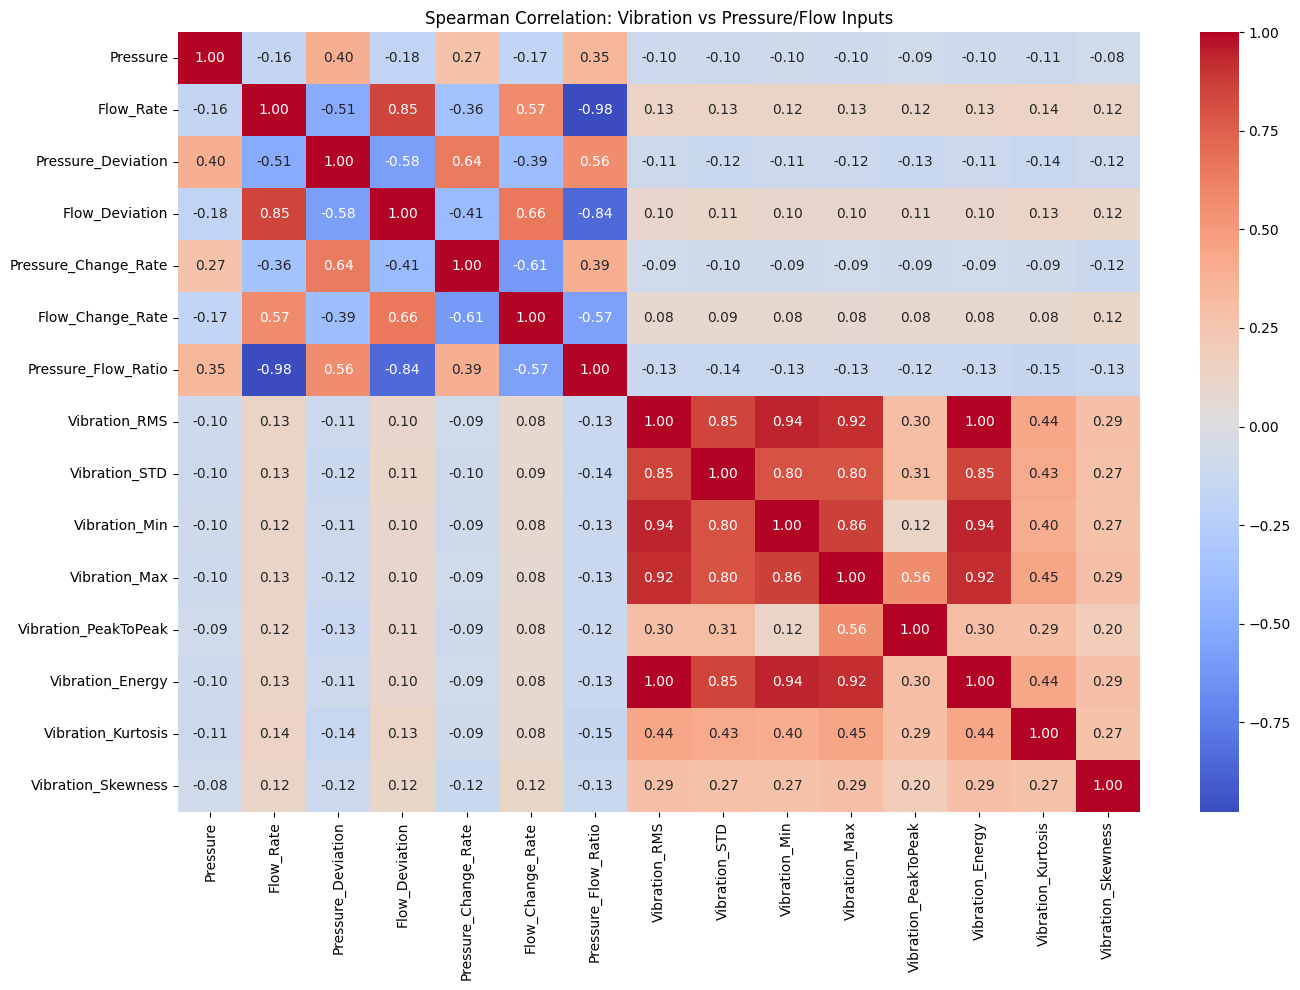

In [7]:
corr_cols = generation_inputs + vibration_cols

corr_matrix = new_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Correlation: Vibration vs Pressure/Flow Inputs")
plt.tight_layout()
plt.show()

#Check if pressure/flow are able to regenerate vibration

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = new_df[generation_inputs]
y_all = new_df[vibration_cols]

train_idx, test_idx = train_test_split(
    np.arange(len(new_df)),
    test_size=0.30,
    random_state=42
)

results = []

for target in vibration_cols:

    model = ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X.iloc[train_idx],
        y_all[target].iloc[train_idx]
    )

    pred = model.predict(X.iloc[test_idx])

    r2 = r2_score(
        y_all[target].iloc[test_idx],
        pred
    )

    mae = mean_absolute_error(
        y_all[target].iloc[test_idx],
        pred
    )

    results.append({
        "Vibration Feature": target,
        "R2": r2,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values("R2", ascending=False)
)

,Vibration Feature,R2,MAE
5,Vibration_Energy,0.676448,0.182351
3,Vibration_Max,0.631717,0.124143
0,Vibration_RMS,0.613698,0.105410
1,Vibration_STD,0.611181,0.048891
6,Vibration_Kurtosis,0.538378,0.120728
2,Vibration_Min,0.499502,0.115536
7,Vibration_Skewness,0.274176,0.063876
4,Vibration_PeakToPeak,0.263737,0.080148


#**Leak Audit**

In [9]:
target_columns = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days",
    "Leak_No_Leak",
    "Leak_Type",
    "Leak_Type_Eligible"
]

print("Target / label related columns:")
for col in target_columns:
    print("-", col)

Target / label related columns:
- Failure_Next_7_Days
- Failure_Next_30_Days
- Failure_Next_90_Days
- Leak_No_Leak
- Leak_Type
- Leak_Type_Eligible


#correlation between vibration and target

In [10]:
numeric_targets = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days",
    "Leak_No_Leak",
    "Leak_Type_Eligible"
]

target_corr = pd.DataFrame(
    index=vibration_cols,
    columns=numeric_targets
)

for v in vibration_cols:
    for t in numeric_targets:
        target_corr.loc[v, t] = new_df[v].corr(
            new_df[t],
            method="spearman"
        )

target_corr = target_corr.astype(float)

display(target_corr)

/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Failure_Next_7_Days,Failure_Next_30_Days,Failure_Next_90_Days,Leak_No_Leak,Leak_Type_Eligible
Vibration_RMS,NaN,0.008059,0.006986,0.318629,0.318629
Vibration_STD,NaN,0.009399,0.007014,0.308915,0.308915
Vibration_Min,NaN,0.007236,0.006038,0.289999,0.289999
Vibration_Max,NaN,0.006203,0.007248,0.317306,0.317306
Vibration_PeakToPeak,NaN,0.002580,0.005767,0.225214,0.225214
Vibration_Energy,NaN,0.008059,0.006986,0.318629,0.318629
Vibration_Kurtosis,NaN,0.005106,-0.000170,0.308079,0.308079
Vibration_Skewness,NaN,-0.000805,-0.002202,0.219269,0.219269


#ال NAn الي ظهر في ال failure next 7 days مش مهم لان كده كده مش هنستخدم الcolumn دي في جزء ال leak detection و هي بالفعل اتعدلت بعد كده في في جزء ال leak prediction

#Does target leak add info to pressure and flow

In [11]:
base_features = [
    "Pressure",
    "Flow_Rate",
    "Pressure_Deviation",
    "Flow_Deviation",
    "Pressure_Change_Rate",
    "Flow_Change_Rate",
    "Pressure_Flow_Ratio"
]

leak_features = base_features + ["Leak_No_Leak"]

comparison = []

for target in vibration_cols:

    # Model A: no target

    model_a = ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    model_a.fit(
        new_df.loc[train_idx, base_features],
        new_df.loc[train_idx, target]
    )

    pred_a = model_a.predict(
        new_df.loc[test_idx, base_features]
    )

    r2_a = r2_score(
        new_df.loc[test_idx, target],
        pred_a
    )


    # Model B: add Leak_No_Leak
    model_b = ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    model_b.fit(
        new_df.loc[train_idx, leak_features],
        new_df.loc[train_idx, target]
    )

    pred_b = model_b.predict(
        new_df.loc[test_idx, leak_features]
    )

    r2_b = r2_score(
        new_df.loc[test_idx, target],
        pred_b
    )

    comparison.append({
        "Feature": target,
        "R2_without_target": r2_a,
        "R2_with_Leak_Label": r2_b,
        "R2_Improvement": r2_b - r2_a
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Feature,R2_without_target,R2_with_Leak_Label,R2_Improvement
0,Vibration_RMS,0.613698,0.612937,-0.000761
1,Vibration_STD,0.611181,0.610485,-0.000696
2,Vibration_Min,0.499502,0.499128,-0.000374
3,Vibration_Max,0.631717,0.630958,-0.000759
4,Vibration_PeakToPeak,0.263737,0.263207,-0.000529
5,Vibration_Energy,0.676448,0.675275,-0.001174
6,Vibration_Kurtosis,0.538378,0.537826,-0.000553
7,Vibration_Skewness,0.274176,0.273614,-0.000562


In [12]:
target_features = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days",
    "Leak_No_Leak",
    "Leak_Type_Eligible"
]

for target_col in target_features:

    print("\n" + "="*70)
    print("Testing:", target_col)
    print("="*70)

    features_with_target = base_features + [target_col]

    for vibration in vibration_cols:

        model = ExtraTreesRegressor(
            n_estimators=100,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            new_df.loc[train_idx, features_with_target],
            new_df.loc[train_idx, vibration]
        )

        pred = model.predict(
            new_df.loc[test_idx, features_with_target]
        )

        r2 = r2_score(
            new_df.loc[test_idx, vibration],
            pred
        )

        print(
            f"{vibration:25s} R² = {r2:.4f}"
        )


Testing: Failure_Next_7_Days
Vibration_RMS             R² = 0.6135
Vibration_STD             R² = 0.6111
Vibration_Min             R² = 0.4994
Vibration_Max             R² = 0.6318
Vibration_PeakToPeak      R² = 0.2634
Vibration_Energy          R² = 0.6761
Vibration_Kurtosis        R² = 0.5381
Vibration_Skewness        R² = 0.2738

Testing: Failure_Next_30_Days
Vibration_RMS             R² = 0.6131
Vibration_STD             R² = 0.6110
Vibration_Min             R² = 0.4990
Vibration_Max             R² = 0.6313
Vibration_PeakToPeak      R² = 0.2633
Vibration_Energy          R² = 0.6760
Vibration_Kurtosis        R² = 0.5382
Vibration_Skewness        R² = 0.2736

Testing: Failure_Next_90_Days
Vibration_RMS             R² = 0.6132
Vibration_STD             R² = 0.6111
Vibration_Min             R² = 0.4987
Vibration_Max             R² = 0.6311
Vibration_PeakToPeak      R² = 0.2627
Vibration_Energy          R² = 0.6759
Vibration_Kurtosis        R² = 0.5383
Vibration_Skewness        R² = 0.2

#check Sensor_Anomaly_Score

In [13]:
sensor_related = [
    "Sensor_Anomaly_Score",
    "Water_Quality_Index",
    "Asset_Risk_Score"
]

check_cols = vibration_cols + sensor_related

display(
    new_df[check_cols].corr(method="spearman")
)

,Vibration_RMS,Vibration_STD,Vibration_Min,Vibration_Max,Vibration_PeakToPeak,Vibration_Energy,Vibration_Kurtosis,Vibration_Skewness,Sensor_Anomaly_Score,Water_Quality_Index,Asset_Risk_Score
Vibration_RMS,1.000000,0.848217,0.938740,0.916272,0.304449,1.000000,0.443469,0.287393,0.557478,-0.033645,0.022962
Vibration_STD,0.848217,1.000000,0.799746,0.797562,0.306265,0.848217,0.427461,0.274661,0.519766,-0.037442,0.024785
Vibration_Min,0.938740,0.799746,1.000000,0.862456,0.120033,0.938740,0.402662,0.266956,0.507033,-0.033812,0.023232
Vibration_Max,0.916272,0.797562,0.862456,1.000000,0.563962,0.916272,0.447118,0.288531,0.561627,-0.033371,0.028211
Vibration_PeakToPeak,0.304449,0.306265,0.120033,0.563962,1.000000,0.304449,0.290549,0.196178,0.336946,-0.039509,0.027166
Vibration_Energy,1.000000,0.848217,0.938740,0.916272,0.304449,1.000000,0.443469,0.287393,0.557478,-0.033645,0.022962
Vibration_Kurtosis,0.443469,0.427461,0.402662,0.447118,0.290549,0.443469,1.000000,0.272813,0.479459,-0.046039,0.036744
Vibration_Skewness,0.287393,0.274661,0.266956,0.288531,0.196178,0.287393,0.272813,1.000000,0.324818,-0.039469,0.012430
Sensor_Anomaly_Score,0.557478,0.519766,0.507033,0.561627,0.336946,0.557478,0.479459,0.324818,1.000000,-0.024492,0.039517
Water_Quality_Index,-0.033645,-0.037442,-0.033812,-0.033371,-0.039509,-0.033645,-0.046039,-0.039469,-0.024492,1.000000,-0.118343


#**conclusion:**
 No target or leak-related labels were used as inputs during the regeneration of the synthetic vibration features. The subsequent audit showed that the regenerated vibration variables were explainable from pressure- and flow-related information, while incorporating target-related variables provided no meaningful additional predictive information. Therefore, the regenerated vibration features were treated as engineered/synthetic features rather than an independent physical sensing modality.

#**FEATURE LEAKAGE AUDIT for  Modified Dataset**

In [24]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error

DATA_PATH = "/content/aqua_grid_pfv_vibration_v2.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("MODIFIED DATASET — FEATURE LEAKAGE AUDIT")
print("=" * 70)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

MODIFIED DATASET — FEATURE LEAKAGE AUDIT
Dataset shape: (100000, 80)
Number of rows: 100000
Number of columns: 80


In [25]:

# LEAK DETECTION TARGET


LEAK_TARGET = "Leak_No_Leak"

LEAK_LABEL_COLUMNS = [
    "Leak_No_Leak",
    "Leak_Type",
    "Leak_Type_Eligible"
]

OUT_OF_SCOPE_FAILURE_COLUMNS = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days"
]

print("Leak Detection Target:")
print(" -", LEAK_TARGET)

print("\nLeak-related label columns:")
for col in LEAK_LABEL_COLUMNS:
    print(" -", col)

print("\nOut-of-scope failure prediction columns:")
for col in OUT_OF_SCOPE_FAILURE_COLUMNS:
    print(" -", col)

Leak Detection Target:
 - Leak_No_Leak

Leak-related label columns:
 - Leak_No_Leak
 - Leak_Type
 - Leak_Type_Eligible

Out-of-scope failure prediction columns:
 - Failure_Next_7_Days
 - Failure_Next_30_Days
 - Failure_Next_90_Days


In [26]:

#  LEAK TARGET DISTRIBUTION


print("Leak_No_Leak distribution:")
print(df[LEAK_TARGET].value_counts(dropna=False))

print("\nLeak_No_Leak proportion:")
print(df[LEAK_TARGET].value_counts(normalize=True, dropna=False))

Leak_No_Leak distribution:
Leak_No_Leak
0    89175
1    10825
Name: count, dtype: int64

Leak_No_Leak proportion:
Leak_No_Leak
0    0.89175
1    0.10825
Name: proportion, dtype: float64


In [27]:

# ALL DATASET COLUMNS


print("All dataset columns:")
print("=" * 70)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

All dataset columns:
01. Asset_ID
02. Asset_Type
03. Pipe_Material
04. Pipe_Diameter_cm
05. Pipe_Length_m
06. Pipe_Depth_m
07. Frost_Depth_m
08. Installation_Year
09. Installation_Date
10. Pipe_Age_Years
11. Condition_Score
12. Criticality
13. Criticality_Score
14. Lined
15. Undersized
16. Shallow_Main
17. Oversized
18. Cleaned
19. Pressure_Sensor_ID
20. Pressure
21. Pressure_Unit
22. Flow_Sensor_ID
23. Flow_Rate
24. Flow_Unit
25. Pressure_Deviation
26. Flow_Deviation
27. Pressure_Change_Rate
28. Flow_Change_Rate
29. Pressure_Flow_Ratio
30. Temperature_C
31. pH
32. TDS_mg_L
33. Turbidity_NTU
34. Dissolved_Oxygen_mg_L
35. Conductivity_umhos_cm
36. BOD_mg_L
37. Nitrate_Nitrite_mg_L
38. Fecal_Coliform_MPN_100ml
39. Total_Coliform_MPN_100ml
40. Timestamp
41. Observation_Date
42. Year
43. Month
44. Day
45. Hour
46. Day_of_Week
47. Season
48. Previous_Failures
49. Failures_Last_1_Year
50. Failures_Last_3_Years
51. Failures_Last_5_Years
52. Days_Since_Last_Failure
53. Vibration_RMS
54. Vibrat

In [28]:

# SYNTHETIC / ENGINEERED FEATURES

vibration_cols = [
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness"
]

acoustic_cols = [
    "Acoustic_RMS",
    "Acoustic_STD",
    "Acoustic_Min",
    "Acoustic_Max",
    "Acoustic_PeakToPeak",
    "Acoustic_Energy",
    "Acoustic_Kurtosis",
    "Acoustic_Skewness"
]

composite_features = [
    "Sensor_Anomaly_Score",
    "Water_Quality_Index",
    "Asset_Risk_Score"
]

print("Vibration features:")
for col in vibration_cols:
    print(" -", col)

print("\nAcoustic features:")
for col in acoustic_cols:
    print(" -", col)

print("\nComposite / engineered scores:")
for col in composite_features:
    print(" -", col)

Vibration features:
 - Vibration_RMS
 - Vibration_STD
 - Vibration_Min
 - Vibration_Max
 - Vibration_PeakToPeak
 - Vibration_Energy
 - Vibration_Kurtosis
 - Vibration_Skewness

Acoustic features:
 - Acoustic_RMS
 - Acoustic_STD
 - Acoustic_Min
 - Acoustic_Max
 - Acoustic_PeakToPeak
 - Acoustic_Energy
 - Acoustic_Kurtosis
 - Acoustic_Skewness

Composite / engineered scores:
 - Sensor_Anomaly_Score
 - Water_Quality_Index
 - Asset_Risk_Score


In [29]:

#  FORBIDDEN TARGET CHECK


all_synthetic_features = (
    vibration_cols +
    acoustic_cols +
    composite_features
)

forbidden_leak_columns = LEAK_LABEL_COLUMNS

print("=" * 70)
print("FORBIDDEN LEAK INFORMATION CHECK")
print("=" * 70)

for feature in all_synthetic_features:

    conflicts = [
        col for col in forbidden_leak_columns
        if col == feature
    ]

    if conflicts:
        print(f"WARNING: {feature} is leak-related!")
    else:
        print(f"OK: {feature}")

FORBIDDEN LEAK INFORMATION CHECK
OK: Vibration_RMS
OK: Vibration_STD
OK: Vibration_Min
OK: Vibration_Max
OK: Vibration_PeakToPeak
OK: Vibration_Energy
OK: Vibration_Kurtosis
OK: Vibration_Skewness
OK: Acoustic_RMS
OK: Acoustic_STD
OK: Acoustic_Min
OK: Acoustic_Max
OK: Acoustic_PeakToPeak
OK: Acoustic_Energy
OK: Acoustic_Kurtosis
OK: Acoustic_Skewness
OK: Sensor_Anomaly_Score
OK: Water_Quality_Index
OK: Asset_Risk_Score


In [30]:

# ACOUSTIC STATISTICAL AUDIT


acoustic_summary = df[acoustic_cols].describe().T

acoustic_summary["skewness"] = df[acoustic_cols].skew()
acoustic_summary["excess_kurtosis"] = df[acoustic_cols].kurtosis()

acoustic_summary["pearson_kurtosis"] = (
    acoustic_summary["excess_kurtosis"] + 3
)

display(acoustic_summary)

,count,mean,std,min,25%,50%,75%,max,skewness,excess_kurtosis,pearson_kurtosis
Acoustic_RMS,100000.0,0.668442,0.289007,0.020000,0.469842,0.666708,0.864008,2.096995,0.093816,-0.161644,2.838356
Acoustic_STD,100000.0,0.282845,0.139089,0.020000,0.184244,0.280630,0.377850,0.966202,0.182859,-0.291843,2.708157
Acoustic_Min,100000.0,0.429813,0.289094,0.005000,0.202457,0.415881,0.626919,1.811630,0.393717,-0.336675,2.663325
Acoustic_Max,100000.0,1.120932,0.349109,0.022371,0.880870,1.118242,1.356588,2.882866,0.075826,-0.099514,2.900486
Acoustic_PeakToPeak,100000.0,0.691119,0.228474,0.008804,0.532494,0.687549,0.845881,1.648843,0.100251,-0.154418,2.845582
Acoustic_Energy,100000.0,0.556791,0.465814,0.001000,0.216238,0.444630,0.773480,4.864320,1.587737,3.965776,6.965776
Acoustic_Kurtosis,100000.0,3.174769,0.779137,1.000000,2.648495,3.173807,3.703374,6.343349,0.015407,-0.068101,2.931899
Acoustic_Skewness,100000.0,0.093479,0.409993,-1.660147,-0.181972,0.092839,0.369675,1.828556,-0.003537,0.035057,3.035057


In [31]:

#  ACOUSTIC FORMULA VALIDATION


acoustic_p2p_error = (
    df["Acoustic_PeakToPeak"] -
    (
        df["Acoustic_Max"] -
        df["Acoustic_Min"]
    )
).abs()

print("Acoustic Peak-to-Peak")
print("Max error :", acoustic_p2p_error.max())
print("Mean error:", acoustic_p2p_error.mean())


acoustic_energy_error = (
    df["Acoustic_Energy"] -
    df["Acoustic_RMS"] ** 2
).abs()

print("\nAcoustic Energy")
print("Max error :", acoustic_energy_error.max())
print("Mean error:", acoustic_energy_error.mean())

Acoustic Peak-to-Peak
Max error : 1.1102230246251565e-15
Mean error: 5.446268436237745e-17

Acoustic Energy
Max error : 1.4281177636478781
Mean error: 0.12081423403907998


In [32]:

#  LEAK TARGET CORRELATION AUDIT


numeric_cols = df.select_dtypes(include=np.number).columns

leak_corr = (
    df[numeric_cols]
    .corr(method="spearman")[LEAK_TARGET]
    .drop(LEAK_TARGET)
    .abs()
    .sort_values(ascending=False)
)

print("Top numerical correlations with Leak_No_Leak:")
print(leak_corr.head(30))

Top numerical correlations with Leak_No_Leak:
Leak_Type_Eligible          1.000000
Pressure_Deviation          0.446685
BOD_mg_L                    0.416683
Turbidity_NTU               0.411594
Flow_Deviation              0.409069
Pressure_Flow_Ratio         0.394397
Flow_Rate                   0.375758
Sensor_Anomaly_Score        0.368341
Water_Demand                0.367402
Pressure_Change_Rate        0.355421
Flow_Change_Rate            0.322645
Vibration_RMS               0.318629
Vibration_Energy            0.318629
Vibration_Max               0.317306
Vibration_STD               0.308915
Vibration_Kurtosis          0.308079
Vibration_Min               0.289999
Vibration_PeakToPeak        0.225214
Pressure                    0.221298
Vibration_Skewness          0.219269
Acoustic_STD                0.173616
Acoustic_RMS                0.164261
Acoustic_Energy             0.157071
Acoustic_Min                0.151819
Acoustic_Max                0.135375
Water_Quality_Index         0

In [33]:

#  SENSOR ANOMALY SCORE AUDIT


sensor_score = "Sensor_Anomaly_Score"

sensor_corr = (
    df.select_dtypes(include=np.number)
      .corr(method="spearman")[sensor_score]
      .drop(sensor_score)
      .abs()
      .sort_values(ascending=False)
)

print("Top correlations with Sensor_Anomaly_Score:")
print(sensor_corr.head(30))

Top correlations with Sensor_Anomaly_Score:
Vibration_Max            0.561627
Vibration_RMS            0.557478
Vibration_Energy         0.557478
Vibration_STD            0.519766
Vibration_Min            0.507033
Vibration_Kurtosis       0.479459
Leak_No_Leak             0.368341
Leak_Type_Eligible       0.368341
Vibration_PeakToPeak     0.336946
Vibration_Skewness       0.324818
BOD_mg_L                 0.264406
Turbidity_NTU            0.239414
Hour                     0.164188
Water_Demand             0.161834
Tank_Level               0.158171
Acoustic_STD             0.151914
Acoustic_RMS             0.148204
Acoustic_Energy          0.141194
Pressure_Change_Rate     0.138834
Acoustic_Min             0.137295
Acoustic_Max             0.121735
Pressure                 0.112692
Flow_Change_Rate         0.108654
Pressure_Flow_Ratio      0.106879
Temperature_C            0.106797
Pressure_Deviation       0.105389
Flow_Rate                0.100316
Dissolved_Oxygen_mg_L    0.091255
Acou

In [34]:

#  SENSOR ANOMALY SCORE STATISTICS


print(
    df["Sensor_Anomaly_Score"].describe()
)

print("\nSkewness:",
      df["Sensor_Anomaly_Score"].skew())

print("Excess Kurtosis:",
      df["Sensor_Anomaly_Score"].kurtosis())

count    100000.000000
mean          0.265477
std           0.187624
min           0.000000
25%           0.134430
50%           0.230677
75%           0.352391
max           1.000000
Name: Sensor_Anomaly_Score, dtype: float64

Skewness: 1.1784940402908641
Excess Kurtosis: 1.6379106670192676


In [35]:

#  SENSOR ANOMALY SCORE RECONSTRUCTION


sensor_inputs = [
    "Pressure",
    "Flow_Rate",
    "Pressure_Deviation",
    "Flow_Deviation",
    "Pressure_Change_Rate",
    "Flow_Change_Rate",
    "Pressure_Flow_Ratio",
    "Temperature_C",
    "pH",
    "TDS_mg_L",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mg_L",
    "Conductivity_umhos_cm",
    "BOD_mg_L",
    "Nitrate_Nitrite_mg_L",
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness",
    "Acoustic_RMS",
    "Acoustic_STD",
    "Acoustic_Min",
    "Acoustic_Max",
    "Acoustic_PeakToPeak",
    "Acoustic_Energy",
    "Acoustic_Kurtosis",
    "Acoustic_Skewness"
]

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.30,
    random_state=42
)

model_sensor = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_sensor.fit(
    df.loc[train_idx, sensor_inputs],
    df.loc[train_idx, sensor_score]
)

pred_sensor = model_sensor.predict(
    df.loc[test_idx, sensor_inputs]
)

sensor_r2 = r2_score(
    df.loc[test_idx, sensor_score],
    pred_sensor
)

sensor_mae = mean_absolute_error(
    df.loc[test_idx, sensor_score],
    pred_sensor
)

print("Sensor Anomaly Score reconstruction")
print("=" * 50)
print("R²  :", sensor_r2)
print("MAE :", sensor_mae)

Sensor Anomaly Score reconstruction
R²  : 0.8062444657799004
MAE : 0.06629547908916071


In [36]:

#  SENSOR ANOMALY SCORE + LEAK TARGET TEST


sensor_inputs_with_leak = sensor_inputs + [
    LEAK_TARGET
]

model_sensor_leak = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_sensor_leak.fit(
    df.loc[train_idx, sensor_inputs_with_leak],
    df.loc[train_idx, sensor_score]
)

pred_sensor_leak = model_sensor_leak.predict(
    df.loc[test_idx, sensor_inputs_with_leak]
)

sensor_r2_with_leak = r2_score(
    df.loc[test_idx, sensor_score],
    pred_sensor_leak
)

print("Sensor Anomaly Score")
print("=" * 50)
print("R² without Leak_No_Leak :", sensor_r2)
print("R² with Leak_No_Leak    :", sensor_r2_with_leak)
print("R² improvement           :", sensor_r2_with_leak - sensor_r2)

Sensor Anomaly Score
R² without Leak_No_Leak : 0.8062444657799004
R² with Leak_No_Leak    : 0.805907730024142
R² improvement           : -0.00033673575575843273


In [37]:

#  ASSET RISK SCORE AUDIT

risk_score = "Asset_Risk_Score"

risk_corr = (
    df.select_dtypes(include=np.number)
      .corr(method="spearman")[risk_score]
      .drop(risk_score)
      .abs()
      .sort_values(ascending=False)
)

print("Top correlations with Asset_Risk_Score:")
print(risk_corr.head(30))

Top correlations with Asset_Risk_Score:
Installation_Year                      0.849997
Pipe_Age_Years                         0.848707
Condition_Score                        0.745705
BOD_mg_L                               0.339841
Failures_Last_1_Year                   0.238692
Pressure_Deviation                     0.238492
Previous_Failures                      0.212881
Failures_Last_3_Years                  0.210518
Failures_Last_5_Years                  0.210518
Criticality_Score                      0.201437
Turbidity_NTU                          0.180900
Acoustic_STD                           0.126004
Pressure                               0.124852
Failure_Next_90_Days                   0.124566
Water_Quality_Index                    0.118343
Acoustic_RMS                           0.112840
Acoustic_Energy                        0.109448
Nitrate_Nitrite_mg_L                   0.104382
Acoustic_Min                           0.104048
Acoustic_Max                           0.093945


In [38]:

#  ASSET RISK INPUTS


risk_inputs = [
    "Pipe_Diameter_cm",
    "Pipe_Length_m",
    "Pipe_Depth_m",
    "Frost_Depth_m",
    "Installation_Year",
    "Pipe_Age_Years",
    "Condition_Score",
    "Criticality_Score",
    "Lined",
    "Undersized",
    "Shallow_Main",
    "Oversized",
    "Cleaned",
    "Previous_Failures",
    "Failures_Last_1_Year",
    "Failures_Last_3_Years",
    "Failures_Last_5_Years",
    "Days_Since_Last_Failure"
]

print("Candidate Asset Risk inputs:")
for col in risk_inputs:
    print(" -", col)

Candidate Asset Risk inputs:
 - Pipe_Diameter_cm
 - Pipe_Length_m
 - Pipe_Depth_m
 - Frost_Depth_m
 - Installation_Year
 - Pipe_Age_Years
 - Condition_Score
 - Criticality_Score
 - Lined
 - Undersized
 - Shallow_Main
 - Oversized
 - Cleaned
 - Previous_Failures
 - Failures_Last_1_Year
 - Failures_Last_3_Years
 - Failures_Last_5_Years
 - Days_Since_Last_Failure


In [39]:

#  ASSET RISK SCORE RECONSTRUCTION


model_risk = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_risk.fit(
    df.loc[train_idx, risk_inputs],
    df.loc[train_idx, risk_score]
)

pred_risk = model_risk.predict(
    df.loc[test_idx, risk_inputs]
)

risk_r2 = r2_score(
    df.loc[test_idx, risk_score],
    pred_risk
)

risk_mae = mean_absolute_error(
    df.loc[test_idx, risk_score],
    pred_risk
)

print("Asset Risk Score reconstruction")
print("=" * 50)
print("R²  :", risk_r2)
print("MAE :", risk_mae)

Asset Risk Score reconstruction
R²  : 0.9729899914933244
MAE : 0.020361025486772856


In [40]:

#  ASSET RISK SCORE + LEAK TARGET TEST

risk_inputs_with_leak = risk_inputs + [
    LEAK_TARGET
]

model_risk_leak = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_risk_leak.fit(
    df.loc[train_idx, risk_inputs_with_leak],
    df.loc[train_idx, risk_score]
)

pred_risk_leak = model_risk_leak.predict(
    df.loc[test_idx, risk_inputs_with_leak]
)

risk_r2_with_leak = r2_score(
    df.loc[test_idx, risk_score],
    pred_risk_leak
)

print("Asset Risk Score")
print("=" * 50)
print("R² without Leak_No_Leak :", risk_r2)
print("R² with Leak_No_Leak    :", risk_r2_with_leak)
print("R² improvement           :", risk_r2_with_leak - risk_r2)

Asset Risk Score
R² without Leak_No_Leak : 0.9729899914933244
R² with Leak_No_Leak    : 0.9730100630552975
R² improvement           : 2.0071561973034058e-05


In [41]:

#  WATER QUALITY INDEX AUDIT


wqi_score = "Water_Quality_Index"

wqi_inputs = [
    "Temperature_C",
    "pH",
    "TDS_mg_L",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mg_L",
    "Conductivity_umhos_cm",
    "BOD_mg_L",
    "Nitrate_Nitrite_mg_L",
    "Fecal_Coliform_MPN_100ml",
    "Total_Coliform_MPN_100ml"
]

wqi_corr = (
    df.select_dtypes(include=np.number)
      .corr(method="spearman")[wqi_score]
      .drop(wqi_score)
      .abs()
      .sort_values(ascending=False)
)

print("Top correlations with Water_Quality_Index:")
print(wqi_corr.head(30))

Top correlations with Water_Quality_Index:
Dissolved_Oxygen_mg_L                  0.681055
Temperature_C                          0.658211
Conductivity_umhos_cm                  0.655158
TDS_mg_L                               0.558559
Month                                  0.495584
Tank_Level                             0.467921
Nitrate_Nitrite_mg_L                   0.325254
Flow_Deviation                         0.308571
Pressure_Flow_Ratio                    0.279751
Pressure_Deviation                     0.277359
Flow_Rate                              0.271144
Turbidity_NTU                          0.238498
Water_Demand                           0.229218
BOD_mg_L                               0.213253
Condition_Score                        0.153591
Leak_Type_Eligible                     0.132158
Leak_No_Leak                           0.132158
Asset_Risk_Score                       0.118343
Installation_Year                      0.118100
Pressure                               0.1180

In [42]:

#  WQI RECONSTRUCTION + LEAK TEST


model_wqi = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_wqi.fit(
    df.loc[train_idx, wqi_inputs],
    df.loc[train_idx, wqi_score]
)

pred_wqi = model_wqi.predict(
    df.loc[test_idx, wqi_inputs]
)

wqi_r2 = r2_score(
    df.loc[test_idx, wqi_score],
    pred_wqi
)

print("WQI reconstruction R²:", wqi_r2)


# Add Leak target
model_wqi_leak = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_wqi_leak.fit(
    df.loc[train_idx, wqi_inputs + [LEAK_TARGET]],
    df.loc[train_idx, wqi_score]
)

pred_wqi_leak = model_wqi_leak.predict(
    df.loc[test_idx, wqi_inputs + [LEAK_TARGET]]
)

wqi_r2_with_leak = r2_score(
    df.loc[test_idx, wqi_score],
    pred_wqi_leak
)

print("WQI R² with Leak_No_Leak:", wqi_r2_with_leak)
print(
    "R² improvement:",
    wqi_r2_with_leak - wqi_r2
)

WQI reconstruction R²: 0.658307536824496
WQI R² with Leak_No_Leak: 0.6572431119911473
R² improvement: -0.0010644248333487871


In [43]:

#  SYNTHETIC FEATURES VS LEAK TARGET


synthetic_features = (
    vibration_cols +
    acoustic_cols +
    composite_features
)

leak_relationship = []

for feature in synthetic_features:

    corr_value = df[feature].corr(
        df[LEAK_TARGET],
        method="spearman"
    )

    leak_relationship.append({
        "Feature": feature,
        "Spearman_Correlation_with_Leak": corr_value,
        "Absolute_Correlation": abs(corr_value)
    })

leak_relationship_df = pd.DataFrame(
    leak_relationship
).sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(leak_relationship_df)

,Feature,Spearman_Correlation_with_Leak,Absolute_Correlation
16,Sensor_Anomaly_Score,0.368341,0.368341
5,Vibration_Energy,0.318629,0.318629
0,Vibration_RMS,0.318629,0.318629
3,Vibration_Max,0.317306,0.317306
1,Vibration_STD,0.308915,0.308915
6,Vibration_Kurtosis,0.308079,0.308079
2,Vibration_Min,0.289999,0.289999
4,Vibration_PeakToPeak,0.225214,0.225214
7,Vibration_Skewness,0.219269,0.219269
9,Acoustic_STD,0.173616,0.173616


In [44]:

#  DIRECT TARGET-DERIVED FEATURE CHECK


forbidden_columns = [
    "Leak_No_Leak",
    "Leak_Type",
    "Leak_Type_Eligible"
]

print("=" * 70)
print("DIRECT LEAK INFORMATION CHECK")
print("=" * 70)

for col in forbidden_columns:

    print(
        f"{col:25s} | "
        f"Exists in dataset: {col in df.columns}"
    )

DIRECT LEAK INFORMATION CHECK
Leak_No_Leak              | Exists in dataset: True
Leak_Type                 | Exists in dataset: True
Leak_Type_Eligible        | Exists in dataset: True


In [45]:

#  FINAL FEATURE AUDIT TABLE


final_audit = pd.DataFrame({

    "Feature_Group": [
        "Vibration",
        "Acoustic",
        "Sensor_Anomaly_Score",
        "Water_Quality_Index",
        "Asset_Risk_Score"
    ],

    "Type": [
        "Synthetic / Engineered",
        "Synthetic / Engineered",
        "Composite / Engineered",
        "Composite / Engineered",
        "Composite / Engineered"
    ],

    "Leak_Label_As_Input": [
        "NO",
        "NO",
        "NO",
        "NO",
        "NO"
    ],

    "Leak_Target": [
        "Leak_No_Leak",
        "Leak_No_Leak",
        "Leak_No_Leak",
        "Leak_No_Leak",
        "Leak_No_Leak"
    ],

    "Independent_Physical_Sensor": [
        "NO",
        "NO",
        "NO",
        "NO",
        "NO"
    ]
})

display(final_audit)

,Feature_Group,Type,Leak_Label_As_Input,Leak_Target,Independent_Physical_Sensor
0,Vibration,Synthetic / Engineered,NO,Leak_No_Leak,NO
1,Acoustic,Synthetic / Engineered,NO,Leak_No_Leak,NO
2,Sensor_Anomaly_Score,Composite / Engineered,NO,Leak_No_Leak,NO
3,Water_Quality_Index,Composite / Engineered,NO,Leak_No_Leak,NO
4,Asset_Risk_Score,Composite / Engineered,NO,Leak_No_Leak,NO


In [46]:

#  FINAL LEAKAGE AUDIT RULES

print("=" * 70)
print("FINAL LEAK DETECTION FEATURE LEAKAGE RULES")
print("=" * 70)

print("""
TARGET:
    Leak_No_Leak

FORBIDDEN LEAK INFORMATION:
    Leak_No_Leak
    Leak_Type
    Leak_Type_Eligible

OUT-OF-SCOPE FAILURE TARGETS:
    Failure_Next_7_Days
    Failure_Next_30_Days
    Failure_Next_90_Days

IMPORTANT:
    The out-of-scope Failure_Next_* columns are NOT targets
    for this Leak Detection task.

    They are only checked to ensure they are not accidentally
    used as predictors or generation inputs.

SYNTHETIC / ENGINEERED FEATURES:
    Vibration_*
    Acoustic_*
    Sensor_Anomaly_Score
    Water_Quality_Index
    Asset_Risk_Score

These features must be generated only from information available
at the prediction time and must not directly use Leak_No_Leak,
Leak_Type, or Leak_Type_Eligible.
""")

FINAL LEAK DETECTION FEATURE LEAKAGE RULES

TARGET:
    Leak_No_Leak

FORBIDDEN LEAK INFORMATION:
    Leak_No_Leak
    Leak_Type
    Leak_Type_Eligible

OUT-OF-SCOPE FAILURE TARGETS:
    Failure_Next_7_Days
    Failure_Next_30_Days
    Failure_Next_90_Days

IMPORTANT:
    The out-of-scope Failure_Next_* columns are NOT targets
    for this Leak Detection task.

    They are only checked to ensure they are not accidentally
    used as predictors or generation inputs.

SYNTHETIC / ENGINEERED FEATURES:
    Vibration_*
    Acoustic_*
    Sensor_Anomaly_Score
    Water_Quality_Index
    Asset_Risk_Score

These features must be generated only from information available
at the prediction time and must not directly use Leak_No_Leak,
Leak_Type, or Leak_Type_Eligible.



#**Conclusion:**
The post-generation leakage audit found no evidence that the leak detection target (Leak_No_Leak) was used as an input to reconstruct the engineered features. Adding the leak target did not improve reconstruction performance for the Sensor Anomaly Score, Asset Risk Score, or Water Quality Index. The synthetic vibration features were also verified for internal consistency and should be treated as engineered/synthetic features rather than independent physical vibration measurements.

#**Part two**
#Case study to see if the modification we did to vibration really made a difference or not

In [1]:

# VIBRATION  STUDY
# XGBoost

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

# FIXED EXPERIMENT SETTINGS


RANDOM_STATE = 42

TARGET = "Leak_No_Leak"

TEST_SIZE = 0.20
VAL_SIZE = 0.20

print("=" * 70)
print("CONTROLLED VIBRATION ABLATION STUDY")
print("=" * 70)

print("Target:", TARGET)
print("Random state:", RANDOM_STATE)
print("Test size:", TEST_SIZE)
print("Validation size:", VAL_SIZE)

CONTROLLED VIBRATION ABLATION STUDY
Target: Leak_No_Leak
Random state: 42
Test size: 0.2
Validation size: 0.2


In [2]:

OLD_PATH = "/content/VIEW_2_ML_dataset_WITH_SCADA_CONTEXT_FINAL (2).csv"
MODIFIED_PATH = "/content/aqua_grid_pfv_vibration_v2.csv"

df_old = pd.read_csv(OLD_PATH)
df_new = pd.read_csv(MODIFIED_PATH)

print("OLD dataset shape     :", df_old.shape)
print("MODIFIED dataset shape:", df_new.shape)

OLD dataset shape     : (100000, 80)
MODIFIED dataset shape: (100000, 80)


In [3]:

# DATASET CONSISTENCY CHECK

print("=" * 70)
print("DATASET CONSISTENCY CHECK")
print("=" * 70)

print("\nOLD shape:")
print(df_old.shape)

print("\nMODIFIED shape:")
print(df_new.shape)

print("\nSame number of rows:",
      len(df_old) == len(df_new))

print("\nSame Asset_ID order:",
      df_old["Asset_ID"].equals(df_new["Asset_ID"]))

print("\nSame target:",
      df_old[TARGET].equals(df_new[TARGET]))

DATASET CONSISTENCY CHECK

OLD shape:
(100000, 80)

MODIFIED shape:
(100000, 80)

Same number of rows: True

Same Asset_ID order: True

Same target: True


In [4]:

# Define vibration columns

vibration_cols = [
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness"
]

print("Vibration features:")
for col in vibration_cols:
    print("-", col)

Vibration features:
- Vibration_RMS
- Vibration_STD
- Vibration_Min
- Vibration_Max
- Vibration_PeakToPeak
- Vibration_Energy
- Vibration_Kurtosis
- Vibration_Skewness


In [5]:

# LEAKAGE / ID / NON-PREDICTOR COLUMNS

leakage_cols = [
    "Leak_Type",
    "Leak_Type_Eligible"
]

future_target_cols = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days"
]

id_date_cols = [
    "Pressure_Sensor_ID",
    "Flow_Sensor_ID",
    "Timestamp",
    "Observation_Date",
    "Installation_Date"
]

constant_cols = [
    "Pressure_Unit",
    "Flow_Unit"
]

base_drop_cols = (
    leakage_cols
    + future_target_cols
    + id_date_cols
    + constant_cols
    + ["Asset_ID"]
)

print("Excluded columns:")
for col in base_drop_cols:
    print("-", col)

Excluded columns:
- Leak_Type
- Leak_Type_Eligible
- Failure_Next_7_Days
- Failure_Next_30_Days
- Failure_Next_90_Days
- Pressure_Sensor_ID
- Flow_Sensor_ID
- Timestamp
- Observation_Date
- Installation_Date
- Pressure_Unit
- Flow_Unit
- Asset_ID


In [6]:
#THREE feature sets

# Condition 1:OLD VIBRATION

old_features = [
    col for col in df_old.columns
    if col not in base_drop_cols + [TARGET]
]



# Condition 2:NO VIBRATION


no_vibration_features = [
    col for col in old_features
    if col not in vibration_cols
]



# Condition 3:REGENERATED VIBRATION


new_features = [
    col for col in df_new.columns
    if col not in base_drop_cols + [TARGET]
]


print("=" * 70)
print("FEATURE SETS")
print("=" * 70)

print("\nOLD VIBRATION:")
print("Number of features:", len(old_features))

print("\nNO VIBRATION:")
print("Number of features:", len(no_vibration_features))

print("\nREGENERATED VIBRATION:")
print("Number of features:", len(new_features))

FEATURE SETS

OLD VIBRATION:
Number of features: 66

NO VIBRATION:
Number of features: 58

REGENERATED VIBRATION:
Number of features: 66


In [7]:
#Verify that the only difference is vibration

old_set = set(old_features)
new_set = set(new_features)

only_in_old = sorted(old_set - new_set)
only_in_new = sorted(new_set - old_set)

print("=" * 70)
print("OLD vs MODIFIED FEATURE DIFFERENCE")
print("=" * 70)

print("\nFeatures only in OLD:")
for col in only_in_old:
    print("-", col)

print("\nFeatures only in MODIFIED:")
for col in only_in_new:
    print("-", col)

OLD vs MODIFIED FEATURE DIFFERENCE

Features only in OLD:

Features only in MODIFIED:


In [8]:

# ONE COMMON GROUP-AWARE SPLIT USED BY ALL THREE EXPERIMENTS

groups = df_new["Asset_ID"]
y = df_new[TARGET].astype(int)


# OUTER SPLIT
# Train+Validation vs Test


gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

trainval_idx, test_idx = next(
    gss1.split(
        df_new,
        y,
        groups=groups
    )
)

# INNER SPLIT
# Train vs Validation

groups_trainval = groups.iloc[trainval_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss2.split(
        df_new.iloc[trainval_idx],
        y.iloc[trainval_idx],
        groups=groups_trainval
    )
)

# Convert inner indices to original dataframe indices
train_idx = trainval_idx[train_idx]
val_idx = trainval_idx[val_idx]


print("=" * 70)
print("COMMON SPLIT")
print("=" * 70)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTotal:", len(train_idx) + len(val_idx) + len(test_idx))

COMMON SPLIT
Train: 64000
Validation: 16000
Test: 20000

Total: 100000


In [9]:
#Verify no group leakage

train_assets = set(df_new.iloc[train_idx]["Asset_ID"])
val_assets = set(df_new.iloc[val_idx]["Asset_ID"])
test_assets = set(df_new.iloc[test_idx]["Asset_ID"])

print("=" * 70)
print("GROUP LEAKAGE CHECK")
print("=" * 70)

print("Train ∩ Validation:",
      len(train_assets.intersection(val_assets)))

print("Train ∩ Test:",
      len(train_assets.intersection(test_assets)))

print("Validation ∩ Test:",
      len(val_assets.intersection(test_assets)))

GROUP LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [10]:
#Check class distribution

print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

for name, idx in [
    ("TRAIN", train_idx),
    ("VALIDATION", val_idx),
    ("TEST", test_idx)
]:

    y_part = y.iloc[idx]

    print(f"\n{name}")
    print(y_part.value_counts())
    print(y_part.value_counts(normalize=True))

CLASS DISTRIBUTION

TRAIN
Leak_No_Leak
0    57067
1     6933
Name: count, dtype: int64
Leak_No_Leak
0    0.891672
1    0.108328
Name: proportion, dtype: float64

VALIDATION
Leak_No_Leak
0    14262
1     1738
Name: count, dtype: int64
Leak_No_Leak
0    0.891375
1    0.108625
Name: proportion, dtype: float64

TEST
Leak_No_Leak
0    17846
1     2154
Name: count, dtype: int64
Leak_No_Leak
0    0.8923
1    0.1077
Name: proportion, dtype: float64


In [11]:
#Function for preprocessing

def prepare_data(
    df,
    feature_cols
):

    X = df[feature_cols].copy()

    bool_cols = X.select_dtypes(
        include="bool"
    ).columns.tolist()

    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    cat_cols = X.select_dtypes(
        include="object"
    ).columns.tolist()

    cat_cols = list(dict.fromkeys(cat_cols))

    num_cols = [
        col for col in X.columns
        if col not in cat_cols
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                num_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="if_binary"
                ),
                cat_cols
            )
        ]
    )

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    X_test = X.iloc[test_idx]

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    return (
        X_train_proc,
        X_val_proc,
        X_test_proc,
        preprocessor,
        num_cols,
        cat_cols
    )

In [12]:

# XGBOOST


def run_xgboost_experiment(
    df,
    feature_cols,
    experiment_name
):

    print("\n")
    print("=" * 70)
    print(experiment_name)
    print("=" * 70)


    # Prepare data


    (
        X_train_proc,
        X_val_proc,
        X_test_proc,
        preprocessor,
        num_cols,
        cat_cols
    ) = prepare_data(
        df,
        feature_cols
    )

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    y_test = y.iloc[test_idx]


    # Same class weighting method as original experiment


    pos = y_train.sum()
    neg = len(y_train) - pos

    scale_pos_weight = neg / pos

    print("Number of features:", len(feature_cols))
    print("scale_pos_weight:", scale_pos_weight)


    #  XGBOOST SETTINGS


    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


    # Train


    model.fit(
        X_train_proc,
        y_train
    )


    # Validation probabilities


    val_proba = model.predict_proba(
        X_val_proc
    )[:, 1]


    # Tune threshold on VALIDATION ONLY



    prec_arr, rec_arr, thr_arr = precision_recall_curve(
        y_val,
        val_proba
    )

    f1_arr = (
        2 * prec_arr * rec_arr
        / (prec_arr + rec_arr + 1e-12)
    )

    best_idx = np.argmax(
        f1_arr[:-1]
    )

    best_thr = thr_arr[best_idx]


    # Test probabilities


    test_proba = model.predict_proba(
        X_test_proc
    )[:, 1]

    test_pred = (
        test_proba >= best_thr
    ).astype(int)

    # Metrics


    accuracy = accuracy_score(
        y_test,
        test_pred
    )

    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        test_proba
    )

    pr_auc = average_precision_score(
        y_test,
        test_proba
    )

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    print("\nThreshold:", round(best_thr, 4))

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC   : {pr_auc:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)


    # Return everything needed for comparison


    return {
        "Experiment": experiment_name,
        "Num_Features": len(feature_cols),
        "Threshold": best_thr,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }

In [13]:

# EXPERIMENT 1 — NO VIBRATION


result_no_vibration = run_xgboost_experiment(
    df=df_new,
    feature_cols=no_vibration_features,
    experiment_name="NO VIBRATION"
)



NO VIBRATION
Number of features: 58
scale_pos_weight: 8.231213039088418

Threshold: 0.3814
Accuracy : 0.9251
Precision: 0.5935
Recall   : 0.9647
F1       : 0.7349
ROC-AUC  : 0.9609
PR-AUC   : 0.6111

Confusion Matrix:
[[16423  1423]
 [   76  2078]]


In [14]:

# EXPERIMENT 2 — OLD VIBRATION


result_old_vibration = run_xgboost_experiment(
    df=df_old,
    feature_cols=old_features,
    experiment_name="OLD VIBRATION"
)



OLD VIBRATION
Number of features: 66
scale_pos_weight: 8.231213039088418

Threshold: 0.2733
Accuracy : 0.9234
Precision: 0.5866
Recall   : 0.9782
F1       : 0.7334
ROC-AUC  : 0.9612
PR-AUC   : 0.6149

Confusion Matrix:
[[16361  1485]
 [   47  2107]]


In [15]:

# EXPERIMENT 3 — REGENERATED VIBRATION

result_regenerated_vibration = run_xgboost_experiment(
    df=df_new,
    feature_cols=new_features,
    experiment_name="REGENERATED VIBRATION"
)



REGENERATED VIBRATION
Number of features: 66
scale_pos_weight: 8.231213039088418

Threshold: 0.3955
Accuracy : 0.9253
Precision: 0.5948
Recall   : 0.9596
F1       : 0.7344
ROC-AUC  : 0.9608
PR-AUC   : 0.6089

Confusion Matrix:
[[16438  1408]
 [   87  2067]]


In [16]:

# FINAL METRICS COMPARISON


results = pd.DataFrame([
    result_no_vibration,
    result_old_vibration,
    result_regenerated_vibration
])

comparison_cols = [
    "Experiment",
    "Num_Features",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]

results = results[
    comparison_cols
]

print("=" * 70)
print("FINAL VIBRATION ABLATION STUDY")
print("=" * 70)

display(
    results.round(4)
)

FINAL VIBRATION ABLATION STUDY


,Experiment,Num_Features,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,NO VIBRATION,58,0.3814,0.9250,0.5935,0.9647,0.7349,0.9609,0.6111,16423,1423,76,2078
1,OLD VIBRATION,66,0.2733,0.9234,0.5866,0.9782,0.7334,0.9612,0.6149,16361,1485,47,2107
2,REGENERATED VIBRATION,66,0.3955,0.9252,0.5948,0.9596,0.7344,0.9608,0.6089,16438,1408,87,2067


In [17]:

# IMPROVEMENT ANALYSIS


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

no_vib = results[
    results["Experiment"] == "NO VIBRATION"
].iloc[0]

old_vib = results[
    results["Experiment"] == "OLD VIBRATION"
].iloc[0]

new_vib = results[
    results["Experiment"] == "REGENERATED VIBRATION"
].iloc[0]


improvement_table = pd.DataFrame({
    "Metric": metrics,

    "No_Vibration": [
        no_vib[m] for m in metrics
    ],

    "Old_Vibration": [
        old_vib[m] for m in metrics
    ],

    "Regenerated_Vibration": [
        new_vib[m] for m in metrics
    ],

    "Old_vs_NoVib": [
        old_vib[m] - no_vib[m]
        for m in metrics
    ],

    "Regenerated_vs_NoVib": [
        new_vib[m] - no_vib[m]
        for m in metrics
    ],

    "Regenerated_vs_Old": [
        new_vib[m] - old_vib[m]
        for m in metrics
    ]
})


print("=" * 70)
print("IMPROVEMENT ANALYSIS")
print("=" * 70)

display(
    improvement_table.round(5)
)

IMPROVEMENT ANALYSIS


,Metric,No_Vibration,Old_Vibration,Regenerated_Vibration,Old_vs_NoVib,Regenerated_vs_NoVib,Regenerated_vs_Old
0,Accuracy,0.92505,0.92340,0.92525,-0.00165,0.00020,0.00185
1,Precision,0.59354,0.58658,0.59482,-0.00696,0.00128,0.00824
2,Recall,0.96472,0.97818,0.95961,0.01346,-0.00511,-0.01857
3,F1,0.73492,0.73338,0.73441,-0.00155,-0.00051,0.00103
4,ROC_AUC,0.96088,0.96117,0.96077,0.00029,-0.00011,-0.00040
5,PR_AUC,0.61107,0.61493,0.60893,0.00386,-0.00215,-0.00600


In [18]:

# PERCENTAGE IMPROVEMENT


percentage_table = improvement_table.copy()

for col in [
    "Old_vs_NoVib",
    "Regenerated_vs_NoVib",
    "Regenerated_vs_Old"
]:

    if col == "Old_vs_NoVib":
        baseline = percentage_table["No_Vibration"]

    elif col == "Regenerated_vs_NoVib":
        baseline = percentage_table["No_Vibration"]

    else:
        baseline = percentage_table["Old_Vibration"]

    percentage_table[
        col + "_Percent"
    ] = (
        percentage_table[col]
        / baseline
        * 100
    )


display(
    percentage_table.round(3)
)

,Metric,No_Vibration,Old_Vibration,Regenerated_Vibration,Old_vs_NoVib,Regenerated_vs_NoVib,Regenerated_vs_Old,Old_vs_NoVib_Percent,Regenerated_vs_NoVib_Percent,Regenerated_vs_Old_Percent
0,Accuracy,0.925,0.923,0.925,-0.002,0.000,0.002,-0.178,0.022,0.200
1,Precision,0.594,0.587,0.595,-0.007,0.001,0.008,-1.173,0.215,1.405
2,Recall,0.965,0.978,0.960,0.013,-0.005,-0.019,1.396,-0.529,-1.898
3,F1,0.735,0.733,0.734,-0.002,-0.001,0.001,-0.210,-0.070,0.141
4,ROC_AUC,0.961,0.961,0.961,0.000,-0.000,-0.000,0.030,-0.011,-0.041
5,PR_AUC,0.611,0.615,0.609,0.004,-0.002,-0.006,0.631,-0.351,-0.976


In [19]:

# AUTOMATIC INTERPRETATION

print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

for metric in metrics:

    no_value = no_vib[metric]
    old_value = old_vib[metric]
    new_value = new_vib[metric]

    old_gain = old_value - no_value
    new_gain = new_value - no_value
    regeneration_gain = new_value - old_value

    print(f"\n{metric}")
    print("-" * 50)

    print(
        f"No Vibration       : {no_value:.4f}"
    )

    print(
        f"Old Vibration      : {old_value:.4f}"
    )

    print(
        f"Regenerated Vib.   : {new_value:.4f}"
    )

    print(
        f"Old vs No Vib      : {old_gain:+.4f}"
    )

    print(
        f"Regenerated vs No  : {new_gain:+.4f}"
    )

    print(
        f"Regenerated vs Old : {regeneration_gain:+.4f}"
    )

INTERPRETATION

Accuracy
--------------------------------------------------
No Vibration       : 0.9251
Old Vibration      : 0.9234
Regenerated Vib.   : 0.9253
Old vs No Vib      : -0.0017
Regenerated vs No  : +0.0002
Regenerated vs Old : +0.0019

Precision
--------------------------------------------------
No Vibration       : 0.5935
Old Vibration      : 0.5866
Regenerated Vib.   : 0.5948
Old vs No Vib      : -0.0070
Regenerated vs No  : +0.0013
Regenerated vs Old : +0.0082

Recall
--------------------------------------------------
No Vibration       : 0.9647
Old Vibration      : 0.9782
Regenerated Vib.   : 0.9596
Old vs No Vib      : +0.0135
Regenerated vs No  : -0.0051
Regenerated vs Old : -0.0186

F1
--------------------------------------------------
No Vibration       : 0.7349
Old Vibration      : 0.7334
Regenerated Vib.   : 0.7344
Old vs No Vib      : -0.0015
Regenerated vs No  : -0.0005
Regenerated vs Old : +0.0010

ROC_AUC
--------------------------------------------------
No V

In [21]:

# SAVE RESULTS


results.to_csv(
    "/content/xgboost_vibration_ablation_results.csv",
    index=False
)

improvement_table.to_csv(
    "/content/xgboost_vibration_improvement.csv",
    index=False
)

percentage_table.to_csv(
    "/content/xgboost_vibration_percentage_improvement.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


#**Conclusion:**
The regenerated vibration features did not provide a measurable performance improvement for leak detection under the controlled experimental setup.Therefore the improvement in leak-detection performance observed in the modified dataset cannot be attributed solely to the regenerated vibration features. The modified dataset contains an expanded feature set compared with the previous experimental setup. Therefore, the observed increase in Accuracy may be partially or primarily explained by the addition of other predictive features rather than by the regeneration of the vibration features itself.

#**Part 3**
GROUP CROSS-VALIDATION STUDY

In [22]:

# XGBoost vs LightGBM vs HistGradientBoosting


import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb



# SETTINGS

RANDOM_STATE = 42
TARGET = "Leak_No_Leak"

N_SPLITS = 5

# Same dataset used in the notebook
DATA_PATH = "/content/aqua_grid_pfv_vibration_v2.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("Target:", TARGET)
print("Number of groups:", df["Asset_ID"].nunique())

print("\nLeak target distribution:")
print(df[TARGET].value_counts())

print("\nLeak target proportion:")
print(df[TARGET].value_counts(normalize=True))

DATASET
Shape: (100000, 80)
Target: Leak_No_Leak
Number of groups: 1250

Leak target distribution:
Leak_No_Leak
0    89175
1    10825
Name: count, dtype: int64

Leak target proportion:
Leak_No_Leak
0    0.89175
1    0.10825
Name: proportion, dtype: float64


In [23]:

# FEATURE SELECTION


leakage_cols = [
    "Leak_Type",
    "Leak_Type_Eligible"
]

future_target_cols = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days"
]

id_date_cols = [
    "Pressure_Sensor_ID",
    "Flow_Sensor_ID",
    "Timestamp",
    "Observation_Date",
    "Installation_Date"
]

constant_cols = [
    "Pressure_Unit",
    "Flow_Unit"
]

# Asset_ID is used ONLY for grouping
#  NOT used as a predictor
drop_cols = (
    leakage_cols
    + future_target_cols
    + id_date_cols
    + constant_cols
    + ["Asset_ID"]
)

X = df.drop(
    columns=drop_cols + [TARGET]
)

y = df[TARGET].astype(int)

groups = df["Asset_ID"]


print("=" * 70)
print("FEATURE SET")
print("=" * 70)

print("Number of predictors:", X.shape[1])

print("\nPredictor columns:")
for i, col in enumerate(X.columns, start=1):
    print(f"{i:02d}. {col}")

FEATURE SET
Number of predictors: 66

Predictor columns:
01. Asset_Type
02. Pipe_Material
03. Pipe_Diameter_cm
04. Pipe_Length_m
05. Pipe_Depth_m
06. Frost_Depth_m
07. Installation_Year
08. Pipe_Age_Years
09. Condition_Score
10. Criticality
11. Criticality_Score
12. Lined
13. Undersized
14. Shallow_Main
15. Oversized
16. Cleaned
17. Pressure
18. Flow_Rate
19. Pressure_Deviation
20. Flow_Deviation
21. Pressure_Change_Rate
22. Flow_Change_Rate
23. Pressure_Flow_Ratio
24. Temperature_C
25. pH
26. TDS_mg_L
27. Turbidity_NTU
28. Dissolved_Oxygen_mg_L
29. Conductivity_umhos_cm
30. BOD_mg_L
31. Nitrate_Nitrite_mg_L
32. Fecal_Coliform_MPN_100ml
33. Total_Coliform_MPN_100ml
34. Year
35. Month
36. Day
37. Hour
38. Day_of_Week
39. Season
40. Previous_Failures
41. Failures_Last_1_Year
42. Failures_Last_3_Years
43. Failures_Last_5_Years
44. Days_Since_Last_Failure
45. Vibration_RMS
46. Vibration_STD
47. Vibration_Min
48. Vibration_Max
49. Vibration_PeakToPeak
50. Vibration_Energy
51. Vibration_Kurt

In [24]:

# DATA TYPES preprocessing


bool_cols = X.select_dtypes(include="bool").columns.tolist()

if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()

# Keep compatibility with string dtype
cat_cols += [
    c for c in X.columns
    if str(X[c].dtype) == "str"
]

cat_cols = list(dict.fromkeys(cat_cols))

num_cols = [
    c for c in X.columns
    if c not in cat_cols
]

print("=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical features:", len(num_cols))
print("Categorical features:", len(cat_cols))

print("\nCategorical:")
print(cat_cols)

FEATURE TYPES
Numerical features: 61
Categorical features: 5

Categorical:
['Asset_Type', 'Pipe_Material', 'Criticality', 'Day_of_Week', 'Season']


In [25]:

# 5-FOLD STRATIFIED GROUP CROSS-VALIDATION


cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_info = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    train_groups = groups.iloc[train_idx].nunique()
    test_groups = groups.iloc[test_idx].nunique()

    train_pos_rate = y.iloc[train_idx].mean()
    test_pos_rate = y.iloc[test_idx].mean()

    overlap = set(
        groups.iloc[train_idx]
    ).intersection(
        set(groups.iloc[test_idx])
    )

    fold_info.append({
        "Fold": fold,
        "Train_Rows": len(train_idx),
        "Test_Rows": len(test_idx),
        "Train_Groups": train_groups,
        "Test_Groups": test_groups,
        "Train_Leak_Rate": train_pos_rate,
        "Test_Leak_Rate": test_pos_rate,
        "Group_Overlap": len(overlap)
    })

fold_info_df = pd.DataFrame(fold_info)

print("=" * 70)
print("GROUP CROSS-VALIDATION STRUCTURE")
print("=" * 70)

display(fold_info_df.round(4))

GROUP CROSS-VALIDATION STRUCTURE


,Fold,Train_Rows,Test_Rows,Train_Groups,Test_Groups,Train_Leak_Rate,Test_Leak_Rate,Group_Overlap
0,1,80000,20000,1000,250,0.1083,0.1081,0
1,2,80000,20000,1000,250,0.1083,0.1080,0
2,3,80000,20000,1000,250,0.1078,0.1101,0
3,4,80000,20000,1000,250,0.1084,0.1078,0
4,5,80000,20000,1000,250,0.1085,0.1073,0


In [26]:

# MODEL

def create_models(scale_pos_weight):

    models = {

        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300,
            max_depth=-1,
            learning_rate=0.1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbosity=-1,
            n_jobs=-1
        ),

        "HistGBM": HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        )
    }

    return models

In [27]:

# PREPROCESSOR FACTORY


def create_preprocessor():

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                num_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="if_binary",
                    sparse_output=False
                ),
                cat_cols
            )
        ]
    )

    return preprocessor

In [28]:
#Inner Validation for Threshold

def find_best_threshold(
    model,
    X_train,
    y_train,
    groups_train,
    X_val,
    y_val
):

    val_proba = model.predict_proba(X_val)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_val,
        val_proba
    )

    # F1 for every threshold
    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-12)
    )

    # precision_recall_curve returns one extra
    # precision/recall value compared with thresholds
    f1_scores = f1_scores[:-1]

    best_idx = np.argmax(f1_scores)

    best_threshold = thresholds[best_idx]

    return best_threshold

In [29]:

# GROUP CV EXPERIMENT


all_results = []
confusion_results = []

print("=" * 70)
print("STARTING GROUP CROSS-VALIDATION")
print("=" * 70)


for fold, (outer_train_idx, outer_test_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    print("\n")
    print("=" * 70)
    print(f"OUTER FOLD {fold}/{N_SPLITS}")
    print("=" * 70)


    # OUTER TRAIN / TEST


    X_outer_train = X.iloc[outer_train_idx].copy()
    y_outer_train = y.iloc[outer_train_idx].copy()

    X_outer_test = X.iloc[outer_test_idx].copy()
    y_outer_test = y.iloc[outer_test_idx].copy()

    groups_outer_train = groups.iloc[outer_train_idx].copy()
    groups_outer_test = groups.iloc[outer_test_idx].copy()


    # VERIFY GROUP SEPARATION


    overlap = set(
        groups_outer_train
    ).intersection(
        set(groups_outer_test)
    )

    assert len(overlap) == 0, \
        f"Group leakage detected in Fold {fold}!"

    print(
        f"Train rows: {len(X_outer_train):,} | "
        f"Test rows: {len(X_outer_test):,}"
    )

    print(
        f"Train groups: {groups_outer_train.nunique():,} | "
        f"Test groups: {groups_outer_test.nunique():,}"
    )

    # INNER GROUP SPLIT Used ONLY for threshold tuning


    inner_gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    inner_train_idx, inner_val_idx = next(
        inner_gss.split(
            X_outer_train,
            y_outer_train,
            groups=groups_outer_train
        )
    )

    X_inner_train = X_outer_train.iloc[inner_train_idx]
    y_inner_train = y_outer_train.iloc[inner_train_idx]

    X_inner_val = X_outer_train.iloc[inner_val_idx]
    y_inner_val = y_outer_train.iloc[inner_val_idx]

    groups_inner_train = groups_outer_train.iloc[inner_train_idx]
    groups_inner_val = groups_outer_train.iloc[inner_val_idx]

    # Verify inner group separation
    inner_overlap = set(
        groups_inner_train
    ).intersection(
        set(groups_inner_val)
    )

    assert len(inner_overlap) == 0, \
        f"Inner group leakage detected in Fold {fold}!"


    # PREPROCESSING FIT ONLY ON INNER TRAIN



    preprocessor = create_preprocessor()

    X_inner_train_proc = preprocessor.fit_transform(
        X_inner_train
    )

    X_inner_val_proc = preprocessor.transform(
        X_inner_val
    )

    X_outer_test_proc = preprocessor.transform(
        X_outer_test
    )


    # CLASS IMBALANCE


    pos = y_inner_train.sum()
    neg = len(y_inner_train) - pos

    scale_pos_weight = neg / pos

    print(
        f"scale_pos_weight: {scale_pos_weight:.4f}"
    )


    # CREATE MODELS


    models = create_models(
        scale_pos_weight
    )


    # TRAIN EACH MODEL


    for model_name, model in models.items():

        print(f"\n--- {model_name} ---")

        # Fit
        model.fit(
            X_inner_train_proc,
            y_inner_train
        )


        # VALIDATION THRESHOLD


        val_proba = model.predict_proba(
            X_inner_val_proc
        )[:, 1]

        precision_arr, recall_arr, threshold_arr = (
            precision_recall_curve(
                y_inner_val,
                val_proba
            )
        )

        f1_arr = (
            2 * precision_arr * recall_arr
            / (precision_arr + recall_arr + 1e-12)
        )

        best_idx = np.argmax(
            f1_arr[:-1]
        )

        best_threshold = threshold_arr[
            best_idx
        ]


        # OUTER TEST


        test_proba = model.predict_proba(
            X_outer_test_proc
        )[:, 1]

        test_pred = (
            test_proba >= best_threshold
        ).astype(int)


        # METRICS


        accuracy = accuracy_score(
            y_outer_test,
            test_pred
        )

        precision_score_value = precision_score(
            y_outer_test,
            test_pred,
            zero_division=0
        )

        recall = recall_score(
            y_outer_test,
            test_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_outer_test,
            test_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_outer_test,
            test_proba
        )

        # PR-AUC
        pr_auc = average_precision_score(
            y_outer_test,
            test_proba
        )


        # STORE RESULTS


        all_results.append({

            "Fold": fold,

            "Model": model_name,

            "Threshold": best_threshold,

            "Accuracy": accuracy,

            "Precision": precision_score_value,

            "Recall": recall,

            "F1": f1,

            "ROC_AUC": roc_auc,

            "PR_AUC": pr_auc
        })


        # CONFUSION MATRIX


        cm = confusion_matrix(
            y_outer_test,
            test_pred
        )

        confusion_results.append({

            "Fold": fold,

            "Model": model_name,

            "TN": cm[0, 0],

            "FP": cm[0, 1],

            "FN": cm[1, 0],

            "TP": cm[1, 1]
        })

        print(
            f"Threshold : {best_threshold:.4f}"
        )

        print(
            f"Accuracy  : {accuracy:.4f}"
        )

        print(
            f"Precision : {precision_score_value:.4f}"
        )

        print(
            f"Recall    : {recall:.4f}"
        )

        print(
            f"F1        : {f1:.4f}"
        )

        print(
            f"ROC-AUC   : {roc_auc:.4f}"
        )

        print(
            f"PR-AUC    : {pr_auc:.4f}"
        )

STARTING GROUP CROSS-VALIDATION


OUTER FOLD 1/5
Train rows: 80,000 | Test rows: 20,000
Train groups: 1,000 | Test groups: 250
scale_pos_weight: 8.3023

--- XGBoost ---
Threshold : 0.3458
Accuracy  : 0.9266
Precision : 0.5998
Recall    : 0.9648
F1        : 0.7397
ROC-AUC   : 0.9625
PR-AUC    : 0.6242

--- LightGBM ---
Threshold : 0.3696
Accuracy  : 0.9258
Precision : 0.5971
Recall    : 0.9644
F1        : 0.7375
ROC-AUC   : 0.9618
PR-AUC    : 0.6266

--- HistGBM ---
Threshold : 0.2492
Accuracy  : 0.9278
Precision : 0.6060
Recall    : 0.9491
F1        : 0.7397
ROC-AUC   : 0.9623
PR-AUC    : 0.6209


OUTER FOLD 2/5
Train rows: 80,000 | Test rows: 20,000
Train groups: 1,000 | Test groups: 250
scale_pos_weight: 8.2767

--- XGBoost ---
Threshold : 0.3302
Accuracy  : 0.9257
Precision : 0.5961
Recall    : 0.9667
F1        : 0.7375
ROC-AUC   : 0.9618
PR-AUC    : 0.6313

--- LightGBM ---
Threshold : 0.4309
Accuracy  : 0.9263
Precision : 0.5998
Recall    : 0.9518
F1        : 0.7359
ROC-AUC   : 0.

In [30]:

# FOLD-LEVEL RESULTS


results_df = pd.DataFrame(
    all_results
)

print("=" * 70)
print("FOLD-LEVEL RESULTS")
print("=" * 70)

display(
    results_df.round(4)
)

FOLD-LEVEL RESULTS


,Fold,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,XGBoost,0.3458,0.9266,0.5998,0.9648,0.7397,0.9625,0.6242
1,1,LightGBM,0.3696,0.9258,0.5971,0.9644,0.7375,0.9618,0.6266
2,1,HistGBM,0.2492,0.9278,0.6060,0.9491,0.7397,0.9623,0.6209
3,2,XGBoost,0.3302,0.9257,0.5961,0.9667,0.7375,0.9618,0.6313
4,2,LightGBM,0.4309,0.9262,0.5998,0.9518,0.7359,0.9610,0.6188
5,2,HistGBM,0.2527,0.9258,0.5994,0.9412,0.7324,0.9603,0.6060
6,3,XGBoost,0.6178,0.9226,0.5981,0.9064,0.7207,0.9586,0.6031
7,3,LightGBM,0.4340,0.9228,0.5926,0.9578,0.7322,0.9580,0.5951
8,3,HistGBM,0.2278,0.9228,0.5931,0.9519,0.7308,0.9585,0.6043
9,4,XGBoost,0.3127,0.9240,0.5896,0.9703,0.7335,0.9600,0.6085


In [31]:

# FINAL MEAN ± STD

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

summary_mean = (
    results_df
    .groupby("Model")[metric_cols]
    .mean()
)

summary_std = (
    results_df
    .groupby("Model")[metric_cols]
    .std(ddof=1)
)

print("=" * 70)
print("FINAL CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    summary_mean.round(4)
)

print("\n")
print("=" * 70)
print("STANDARD DEVIATION")
print("=" * 70)

display(
    summary_std.round(4)
)

FINAL CROSS-VALIDATION RESULTS


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
HistGBM,0.9251,0.5965,0.9515,0.7333,0.9606,0.6124
LightGBM,0.9244,0.5933,0.9595,0.7332,0.9597,0.6077
XGBoost,0.9244,0.5937,0.9550,0.7321,0.9606,0.6140




STANDARD DEVIATION


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
HistGBM,0.0019,0.0065,0.0110,0.0038,0.0018,0.0132
LightGBM,0.0015,0.0051,0.0053,0.0034,0.0016,0.0145
XGBoost,0.0017,0.0062,0.0272,0.0076,0.0015,0.0130


In [32]:

# FINAL TABLE: MEAN ± STD


final_summary = pd.DataFrame(
    index=summary_mean.index
)

for metric in metric_cols:

    final_summary[metric] = (
        summary_mean[metric].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + summary_std[metric].map(
            lambda x: f"{x:.4f}"
        )
    )

print("=" * 70)
print("FINAL MODEL COMPARISON — MEAN ± STD")
print("=" * 70)

display(final_summary)

FINAL MODEL COMPARISON — MEAN ± STD


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
HistGBM,0.9251 ± 0.0019,0.5965 ± 0.0065,0.9515 ± 0.0110,0.7333 ± 0.0038,0.9606 ± 0.0018,0.6124 ± 0.0132
LightGBM,0.9244 ± 0.0015,0.5933 ± 0.0051,0.9595 ± 0.0053,0.7332 ± 0.0034,0.9597 ± 0.0016,0.6077 ± 0.0145
XGBoost,0.9244 ± 0.0017,0.5937 ± 0.0062,0.9550 ± 0.0272,0.7321 ± 0.0076,0.9606 ± 0.0015,0.6140 ± 0.0130


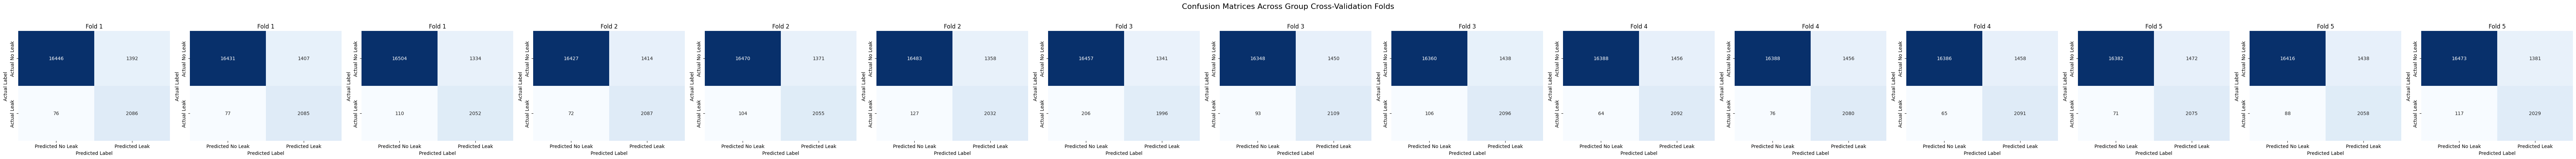

In [37]:

# VISUAL CONFUSION MATRICES BY FOLD


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm_df = pd.DataFrame(confusion_results)

n_folds = len(cm_df)

fig, axes = plt.subplots(
    1,
    n_folds,
    figsize=(5 * n_folds, 4.5)
)

# لو فيه Fold واحدة فقط
if n_folds == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, cm_df.iterrows()):

    cm = np.array([
        [row["TN"], row["FP"]],
        [row["FN"], row["TP"]]
    ])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Predicted No Leak", "Predicted Leak"],
        yticklabels=["Actual No Leak", "Actual Leak"]
    )

    ax.set_title(f"Fold {row['Fold']}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.suptitle(
    "Confusion Matrices Across Group Cross-Validation Folds",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [34]:

# SAVE RESULTS


results_df.to_csv(
    "/content/group_cv_fold_results.csv",
    index=False
)

final_summary.to_csv(
    "/content/group_cv_mean_std_results.csv"
)

cm_df.to_csv(
    "/content/group_cv_confusion_matrices.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


#**Conclusion**
Across the 5-fold group cross-validation, XGBoost achieved the highest mean PR-AUC (0.6140 ± 0.0130), followed closely by HistGBM (0.6124 ± 0.0132) and LightGBM (0.6077 ± 0.0145). Overall, the three models demonstrated comparable performance, with XGBoost providing the best average PR-AUC and HistGBM achieving the highest mean accuracy and F1-score, while LightGBM achieved the highest recall.

#**Part 4**
SHAP ANALYSIS — XGBOOST

In [43]:

# MODEL SETUP


import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("SHAP ANALYSIS — XGBOOST")
print("=" * 70)


# Use the SAME Group CV structure


shap_train_idx, shap_test_idx = next(
    cv.split(X, y, groups=groups)
)

X_shap_train = X.iloc[shap_train_idx].copy()
y_shap_train = y.iloc[shap_train_idx].copy()

X_shap_test = X.iloc[shap_test_idx].copy()
y_shap_test = y.iloc[shap_test_idx].copy()

groups_shap_train = groups.iloc[shap_train_idx]
groups_shap_test = groups.iloc[shap_test_idx]

# Verify no group overlap

overlap = set(groups_shap_train).intersection(
    set(groups_shap_test)
)

assert len(overlap) == 0, "GROUP LEAKAGE DETECTED!"

print("Train rows:", len(X_shap_train))
print("Test rows :", len(X_shap_test))
print("Train groups:", groups_shap_train.nunique())
print("Test groups :", groups_shap_test.nunique())
print("Group overlap:", len(overlap))



# Preprocessing
# SAME preprocessing used in Group CV


shap_preprocessor = create_preprocessor()

X_shap_train_proc = shap_preprocessor.fit_transform(
    X_shap_train
)

X_shap_test_proc = shap_preprocessor.transform(
    X_shap_test
)



# SAME class weighting

pos = y_shap_train.sum()
neg = len(y_shap_train) - pos

shap_scale_pos_weight = neg / pos

print(
    "scale_pos_weight:",
    round(shap_scale_pos_weight, 4)
)


# SAME XGBoost settings


xgb_shap_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=shap_scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_shap_model.fit(
    X_shap_train_proc,
    y_shap_train
)

print("\nXGBoost model trained successfully.")

SHAP ANALYSIS — XGBOOST
Train rows: 80000
Test rows : 20000
Train groups: 1000
Test groups : 250
Group overlap: 0
scale_pos_weight: 8.2347

XGBoost model trained successfully.


In [44]:
#Recover the actual feature names after preprocessing

feature_names = (
    shap_preprocessor
    .get_feature_names_out()
)

print("=" * 70)
print("PROCESSED FEATURE SPACE")
print("=" * 70)

print("Number of processed features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(f"{i:03d}. {feature}")

PROCESSED FEATURE SPACE
Number of processed features: 82
001. num__Pipe_Diameter_cm
002. num__Pipe_Length_m
003. num__Pipe_Depth_m
004. num__Frost_Depth_m
005. num__Installation_Year
006. num__Pipe_Age_Years
007. num__Condition_Score
008. num__Criticality_Score
009. num__Lined
010. num__Undersized
011. num__Shallow_Main
012. num__Oversized
013. num__Cleaned
014. num__Pressure
015. num__Flow_Rate
016. num__Pressure_Deviation
017. num__Flow_Deviation
018. num__Pressure_Change_Rate
019. num__Flow_Change_Rate
020. num__Pressure_Flow_Ratio
021. num__Temperature_C
022. num__pH
023. num__TDS_mg_L
024. num__Turbidity_NTU
025. num__Dissolved_Oxygen_mg_L
026. num__Conductivity_umhos_cm
027. num__BOD_mg_L
028. num__Nitrate_Nitrite_mg_L
029. num__Fecal_Coliform_MPN_100ml
030. num__Total_Coliform_MPN_100ml
031. num__Year
032. num__Month
033. num__Day
034. num__Hour
035. num__Previous_Failures
036. num__Failures_Last_1_Year
037. num__Failures_Last_3_Years
038. num__Failures_Last_5_Years
039. num__Da

In [45]:

# GLOBAL SHAP VALUES


print("=" * 70)
print("GLOBAL SHAP ANALYSIS")
print("=" * 70)


# SHAP sample


SHAP_SAMPLE_SIZE = min(
    10000,
    X_shap_test_proc.shape[0]
)

rng = np.random.RandomState(
    RANDOM_STATE
)

shap_sample_idx = rng.choice(
    X_shap_test_proc.shape[0],
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap_sample = X_shap_test_proc[
    shap_sample_idx
]

y_shap_sample = y_shap_test.iloc[
    shap_sample_idx
].values


print("SHAP sample size:", SHAP_SAMPLE_SIZE)



# TreeExplainer


explainer = shap.TreeExplainer(
    xgb_shap_model
)

shap_values = explainer.shap_values(
    X_shap_sample
)

print(
    "SHAP matrix shape:",
    np.array(shap_values).shape
)

GLOBAL SHAP ANALYSIS
SHAP sample size: 10000
SHAP matrix shape: (10000, 82)


In [46]:

# GLOBAL SHAP — FEATURE IMPORTANCE


mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

global_shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("TOP GLOBAL SHAP FEATURES")
print("=" * 70)

display(
    global_shap_df.head(30)
)

TOP GLOBAL SHAP FEATURES


,Feature,Mean_Absolute_SHAP
0,num__BOD_mg_L,3.018252
1,num__Pressure_Deviation,1.410553
2,num__Turbidity_NTU,1.092515
3,num__Flow_Deviation,0.817773
4,num__Hour,0.527582
5,num__Condition_Score,0.507423
6,num__Sensor_Anomaly_Score,0.184388
7,num__Water_Demand,0.180635
8,num__Acoustic_STD,0.125911
9,num__Pressure_Flow_Ratio,0.116453


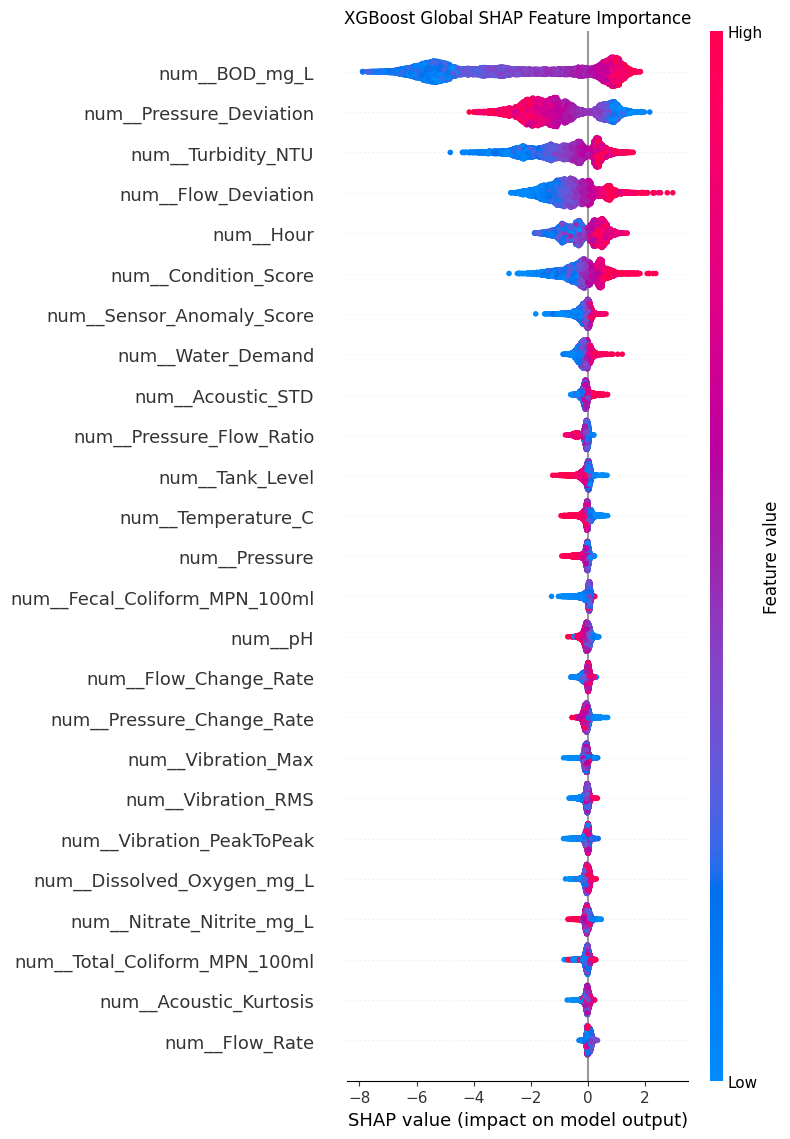

In [47]:

# SHAP SUMMARY PLOT


plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_names,
    max_display=25,
    show=False
)

plt.title(
    "XGBoost Global SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

In [48]:

# SENSOR GROUP SHAP ANALYSIS


pressure_features = [
    "Pressure",
    "Pressure_Deviation",
    "Pressure_Change_Rate"
]

flow_features = [
    "Flow_Rate",
    "Flow_Deviation",
    "Flow_Change_Rate",
    "Pressure_Flow_Ratio"
]

vibration_features = [
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness"
]


def get_processed_indices(
    original_features,
    processed_names
):

    indices = []

    for i, name in enumerate(processed_names):

        clean_name = name.split("__", 1)[-1]

        if clean_name in original_features:
            indices.append(i)

    return indices


pressure_idx = get_processed_indices(
    pressure_features,
    feature_names
)

flow_idx = get_processed_indices(
    flow_features,
    feature_names
)

vibration_idx = get_processed_indices(
    vibration_features,
    feature_names
)



# Calculate group SHAP


group_shap = pd.DataFrame({

    "Sensor_Group": [
        "Pressure",
        "Flow",
        "Vibration"
    ],

    "Mean_Absolute_SHAP": [

        np.abs(
            shap_values[:, pressure_idx]
        ).sum(axis=1).mean(),

        np.abs(
            shap_values[:, flow_idx]
        ).sum(axis=1).mean(),

        np.abs(
            shap_values[:, vibration_idx]
        ).sum(axis=1).mean()
    ]
})

group_shap["Relative_Contribution"] = (
    group_shap["Mean_Absolute_SHAP"]
    /
    group_shap["Mean_Absolute_SHAP"].sum()
)

group_shap = group_shap.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

print("=" * 70)
print("PRESSURE vs FLOW vs VIBRATION")
print("=" * 70)

display(
    group_shap.round(4)
)

PRESSURE vs FLOW vs VIBRATION


,Sensor_Group,Mean_Absolute_SHAP,Relative_Contribution
0,Pressure,1.5995,0.5165
1,Flow,1.0810,0.3490
2,Vibration,0.4165,0.1345


In [49]:

# SHAP BY CLASS(Leak vs No-Leak SHAP)

leak_mask = (
    y_shap_sample == 1
)

no_leak_mask = (
    y_shap_sample == 0
)

class_shap_df = pd.DataFrame({

    "Feature": feature_names,

    "Leak_Mean_Abs_SHAP": np.abs(
        shap_values[leak_mask]
    ).mean(axis=0),

    "No_Leak_Mean_Abs_SHAP": np.abs(
        shap_values[no_leak_mask]
    ).mean(axis=0)
})

class_shap_df["Difference"] = (
    class_shap_df["Leak_Mean_Abs_SHAP"]
    -
    class_shap_df["No_Leak_Mean_Abs_SHAP"]
)

class_shap_df["Abs_Difference"] = (
    class_shap_df["Difference"]
    .abs()
)

class_shap_df = class_shap_df.sort_values(
    "Abs_Difference",
    ascending=False
)

print("=" * 70)
print("SHAP DIFFERENCE — LEAK vs NO LEAK")
print("=" * 70)

display(
    class_shap_df.head(30).round(4)
)

SHAP DIFFERENCE — LEAK vs NO LEAK


,Feature,Leak_Mean_Abs_SHAP,No_Leak_Mean_Abs_SHAP,Difference,Abs_Difference
26,num__BOD_mg_L,0.9041,3.2679,-2.3638,2.3638
23,num__Turbidity_NTU,0.3939,1.1750,-0.7811,0.7811
15,num__Pressure_Deviation,0.8741,1.4739,-0.5998,0.5998
16,num__Flow_Deviation,0.5823,0.8456,-0.2633,0.2633
6,num__Condition_Score,0.3286,0.5285,-0.1999,0.1999
33,num__Hour,0.3809,0.5449,-0.1640,0.1640
59,num__Water_Demand,0.0995,0.1902,-0.0907,0.0907
19,num__Pressure_Flow_Ratio,0.0356,0.1260,-0.0904,0.0904
55,num__Sensor_Anomaly_Score,0.1143,0.1927,-0.0783,0.0783
48,num__Acoustic_STD,0.0740,0.1320,-0.0581,0.0581


In [50]:

# LOCAL SHAP — INDIVIDUAL CASES
# Select one Leak case

leak_positions = np.where(
    y_shap_sample == 1
)[0]

no_leak_positions = np.where(
    y_shap_sample == 0
)[0]


# Choose representative cases
# using highest predicted leak probability

sample_proba = (
    xgb_shap_model
    .predict_proba(X_shap_sample)[:, 1]
)

leak_case_pos = leak_positions[
    np.argmax(
        sample_proba[leak_positions]
    )
]

no_leak_case_pos = no_leak_positions[
    np.argmin(
        sample_proba[no_leak_positions]
    )
]


print("=" * 70)
print("SELECTED LOCAL CASES")
print("=" * 70)

print(
    "Leak case predicted probability:",
    round(
        sample_proba[leak_case_pos],
        4
    )
)

print(
    "No-leak case predicted probability:",
    round(
        sample_proba[no_leak_case_pos],
        4
    )
)

SELECTED LOCAL CASES
Leak case predicted probability: 0.9851
No-leak case predicted probability: 0.0


LOCAL SHAP — LEAK CASE


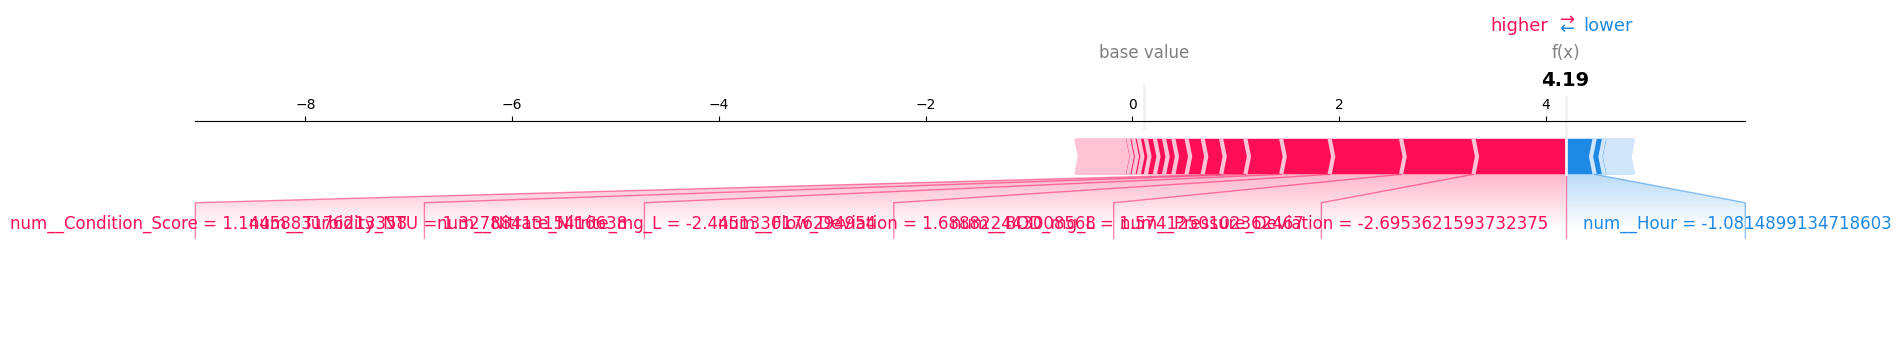

<Figure size 640x480 with 0 Axes>

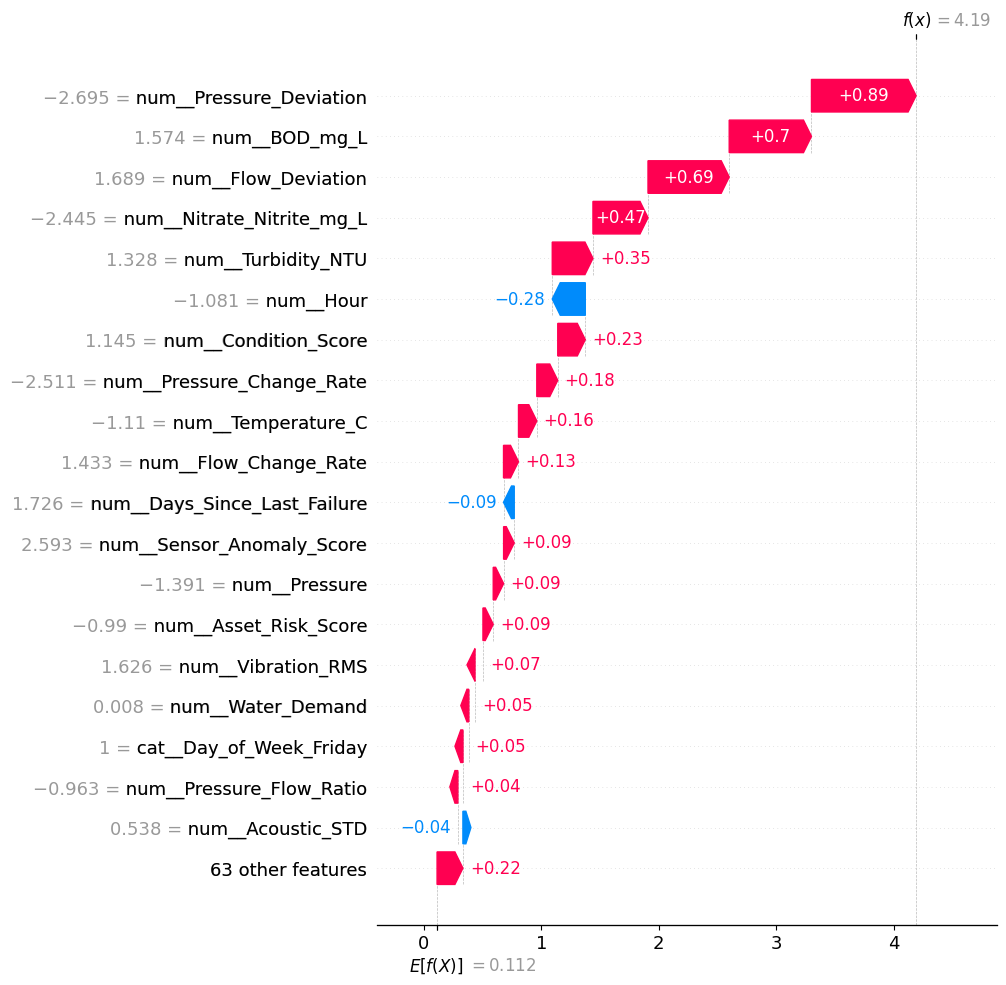

In [51]:

# LOCAL SHAP — LEAK CASE


print("=" * 70)
print("LOCAL SHAP — LEAK CASE")
print("=" * 70)

shap.force_plot(
    explainer.expected_value,
    shap_values[leak_case_pos],
    X_shap_sample[leak_case_pos],
    feature_names=feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()


# Waterfall plot

leak_explanation = shap.Explanation(
    values=shap_values[leak_case_pos],
    base_values=explainer.expected_value,
    data=X_shap_sample[leak_case_pos],
    feature_names=feature_names
)

shap.plots.waterfall(
    leak_explanation,
    max_display=20
)

LOCAL SHAP — NO LEAK CASE


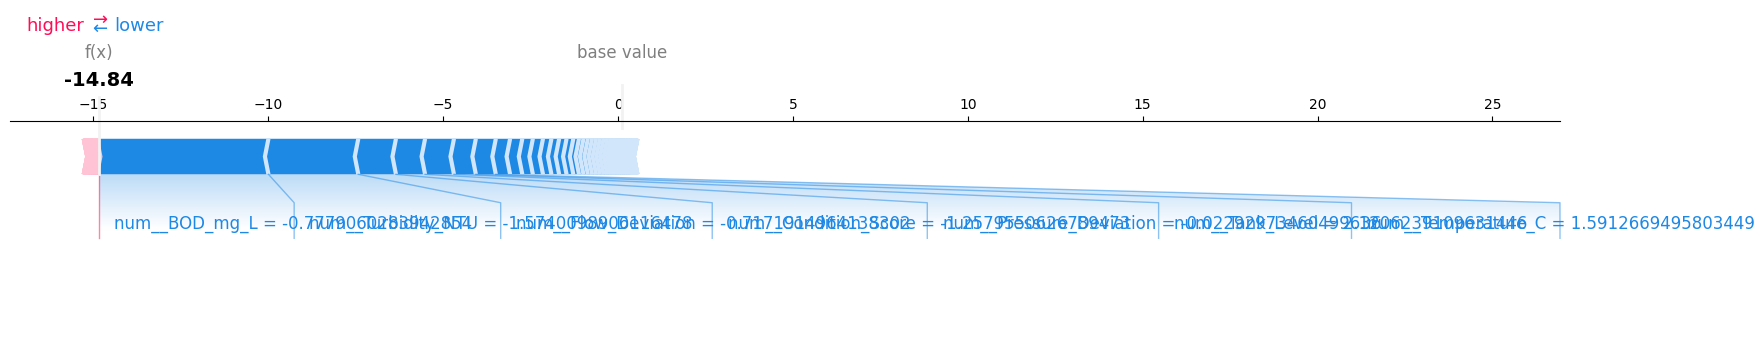

<Figure size 640x480 with 0 Axes>

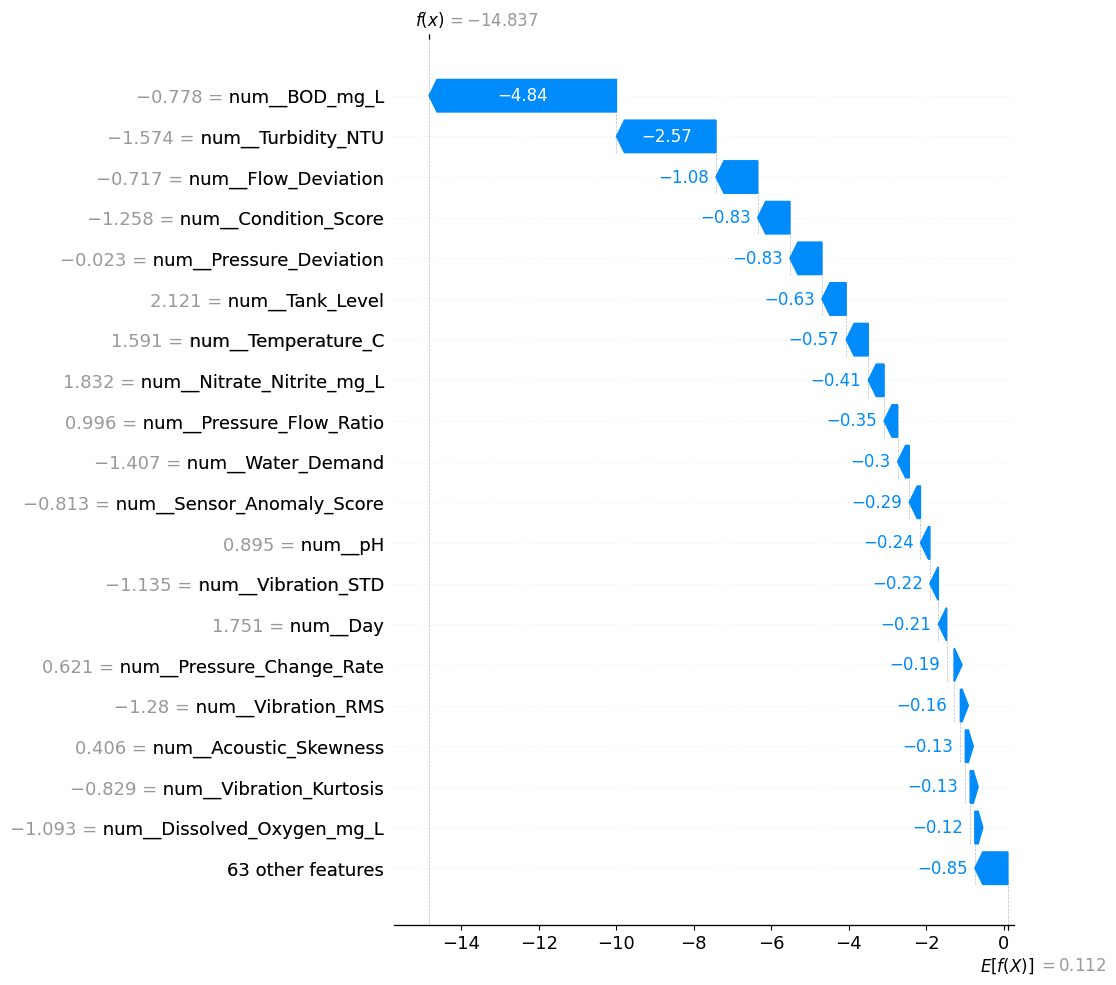

In [52]:

# LOCAL SHAP — NO LEAK CASE


print("=" * 70)
print("LOCAL SHAP — NO LEAK CASE")
print("=" * 70)

shap.force_plot(
    explainer.expected_value,
    shap_values[no_leak_case_pos],
    X_shap_sample[no_leak_case_pos],
    feature_names=feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()


# Waterfall plot

no_leak_explanation = shap.Explanation(
    values=shap_values[no_leak_case_pos],
    base_values=explainer.expected_value,
    data=X_shap_sample[no_leak_case_pos],
    feature_names=feature_names
)

shap.plots.waterfall(
    no_leak_explanation,
    max_display=20
)

In [53]:

# LOCAL SENSOR CONTRIBUTION


def local_group_contribution(
    shap_row,
    feature_names
):

    result = {}

    groups_dict = {
        "Pressure": pressure_features,
        "Flow": flow_features,
        "Vibration": vibration_features
    }

    for group_name, original_features in groups_dict.items():

        indices = get_processed_indices(
            original_features,
            feature_names
        )

        result[group_name] = {
            "Absolute_SHAP": np.abs(
                shap_row[indices]
            ).sum(),

            "Signed_SHAP": (
                shap_row[indices].sum()
            )
        }

    return pd.DataFrame(result).T


print("=" * 70)
print("LEAK CASE — SENSOR CONTRIBUTION")
print("=" * 70)

leak_group_local = local_group_contribution(
    shap_values[leak_case_pos],
    feature_names
)

display(
    leak_group_local.round(4)
)


print("=" * 70)
print("NO-LEAK CASE — SENSOR CONTRIBUTION")
print("=" * 70)

no_leak_group_local = local_group_contribution(
    shap_values[no_leak_case_pos],
    feature_names
)

display(
    no_leak_group_local.round(4)
)

LEAK CASE — SENSOR CONTRIBUTION


,Absolute_SHAP,Signed_SHAP
Pressure,1.1574,1.1574
Flow,0.8809,0.8809
Vibration,0.1976,0.0631


NO-LEAK CASE — SENSOR CONTRIBUTION


,Absolute_SHAP,Signed_SHAP
Pressure,1.0785,-0.9601
Flow,1.5893,-1.5893
Vibration,0.8185,-0.7294


#**Conclusion:**
The SHAP analysis shows that Pressure and Flow provide the strongest contributions to the XGBoost leak detection decisions, while Vibration provides an additional, distinct contribution.

For the selected leak case, Pressure and Flow produced the largest absolute SHAP contributions, while Vibration had a smaller but non-zero contribution. This indicates that the leak decision was primarily driven by pressure- and flow-related information, with vibration providing additional supporting information. For the selected no-leak case, Flow had the largest contribution, followed by Pressure and Vibration. Importantly, the vibration contribution was strongly negative, indicating that the vibration-related features actively contributed to the model's no-leak prediction rather than being ignored.

#**Part5**
SVM vs XGBoost  Original Feature Sets that was used before in anoter notebook.
we will not use the exact feature sets in both models but we will unify dataset + target + groups + folds + evaluation protocol

In [1]:


import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = "/content/aqua_grid_pfv_vibration_v2.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("MODIFIED DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

MODIFIED DATASET
Shape: (100000, 80)
Rows: 100000
Columns: 80


In [2]:

#  TARGET + LEAKAGE / EXCLUSION DEFINITIONS

TARGET = "Leak_No_Leak"
GROUP_COLUMN = "Asset_ID"

leakage_cols = [
    "Leak_Type",
    "Leak_Type_Eligible"
]

future_target_cols = [
    "Failure_Next_7_Days",
    "Failure_Next_30_Days",
    "Failure_Next_90_Days"
]

id_date_cols = [
    "Pressure_Sensor_ID",
    "Flow_Sensor_ID",
    "Timestamp",
    "Observation_Date",
    "Installation_Date"
]

constant_cols = [
    "Pressure_Unit",
    "Flow_Unit"
]

drop_cols = (
    leakage_cols
    + future_target_cols
    + id_date_cols
    + constant_cols
    + [GROUP_COLUMN]
)

print("=" * 70)
print("TARGET / EXCLUSIONS")
print("=" * 70)

print("Target:", TARGET)
print("Group:", GROUP_COLUMN)

print("\nExcluded leakage columns:")
for c in leakage_cols:
    print("-", c)

print("\nExcluded future failure columns:")
for c in future_target_cols:
    print("-", c)

TARGET / EXCLUSIONS
Target: Leak_No_Leak
Group: Asset_ID

Excluded leakage columns:
- Leak_Type
- Leak_Type_Eligible

Excluded future failure columns:
- Failure_Next_7_Days
- Failure_Next_30_Days
- Failure_Next_90_Days


In [3]:
#SAME split that both models will use

y = df[TARGET].astype(int)
groups = df[GROUP_COLUMN]


# STEP 1: 80% DEVELOPMENT / 20% TEST

gss_outer = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dev_idx, test_idx = next(
    gss_outer.split(
        df,
        y,
        groups=groups
    )
)

# STEP 2: 80% TRAIN / 20% VALIDATION

gss_inner = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_rel_idx, val_rel_idx = next(
    gss_inner.split(
        df.iloc[dev_idx],
        y.iloc[dev_idx],
        groups=groups.iloc[dev_idx]
    )
)

train_idx = dev_idx[train_rel_idx]
val_idx = dev_idx[val_rel_idx]

# CHECK GROUP OVERLAP

train_groups = set(groups.iloc[train_idx])
val_groups = set(groups.iloc[val_idx])
test_groups = set(groups.iloc[test_idx])

print("=" * 70)
print("SHARED GROUP SPLIT")
print("=" * 70)

print("Train rows:", len(train_idx))
print("Validation rows:", len(val_idx))
print("Test rows:", len(test_idx))

print("\nTrain groups:", len(train_groups))
print("Validation groups:", len(val_groups))
print("Test groups:", len(test_groups))

print("\nGroup overlap:")
print("Train ∩ Validation:", len(train_groups & val_groups))
print("Train ∩ Test:", len(train_groups & test_groups))
print("Validation ∩ Test:", len(val_groups & test_groups))

print("\nLeak rate:")
print("Train:", y.iloc[train_idx].mean())
print("Validation:", y.iloc[val_idx].mean())
print("Test:", y.iloc[test_idx].mean())

SHARED GROUP SPLIT
Train rows: 64000
Validation rows: 16000
Test rows: 20000

Train groups: 800
Validation groups: 200
Test groups: 250

Group overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Leak rate:
Train: 0.108328125
Validation: 0.108625
Test: 0.1077


In [4]:
#SVM feature set

pressure_features = [
    "Pressure",
    "Pressure_Deviation",
    "Pressure_Change_Rate"
]

flow_features = [
    "Flow_Rate",
    "Flow_Deviation",
    "Flow_Change_Rate",
    "Pressure_Flow_Ratio"
]

vibration_features = [
    "Vibration_RMS",
    "Vibration_STD",
    "Vibration_Min",
    "Vibration_Max",
    "Vibration_PeakToPeak",
    "Vibration_Energy",
    "Vibration_Kurtosis",
    "Vibration_Skewness"
]

print("=" * 70)
print("STACKED SVM FEATURE SET")
print("=" * 70)

print("Pressure:", pressure_features)
print("Flow:", flow_features)
print("Vibration:", vibration_features)

STACKED SVM FEATURE SET
Pressure: ['Pressure', 'Pressure_Deviation', 'Pressure_Change_Rate']
Flow: ['Flow_Rate', 'Flow_Deviation', 'Flow_Change_Rate', 'Pressure_Flow_Ratio']
Vibration: ['Vibration_RMS', 'Vibration_STD', 'Vibration_Min', 'Vibration_Max', 'Vibration_PeakToPeak', 'Vibration_Energy', 'Vibration_Kurtosis', 'Vibration_Skewness']


In [5]:
#Prepare SVM branches

X_pressure = df[pressure_features].copy()
X_flow = df[flow_features].copy()
X_vibration = df[vibration_features].copy()

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

print("Pressure features:", X_pressure.shape[1])
print("Flow features:", X_flow.shape[1])
print("Vibration features:", X_vibration.shape[1])

Pressure features: 3
Flow features: 4
Vibration features: 8


In [6]:
#SVM training

svm_param_dist = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

def train_svm_branch(X, name):

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X.iloc[train_idx]
    )

    X_val = scaler.transform(
        X.iloc[val_idx]
    )

    X_test = scaler.transform(
        X.iloc[test_idx]
    )

    svm = SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=False,
        random_state=RANDOM_STATE
    )

    search = RandomizedSearchCV(
        estimator=svm,
        param_distributions=svm_param_dist,
        n_iter=8,
        scoring="f1",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train
    )

    print(f"\n{name}")
    print("-" * 50)
    print("Best parameters:", search.best_params_)
    print("Best CV F1:", search.best_score_)

    return (
        search.best_estimator_,
        scaler,
        X_train,
        X_val,
        X_test
    )


pressure_svm, pressure_scaler, \
pressure_train, pressure_val, pressure_test = train_svm_branch(
    X_pressure,
    "PRESSURE SVM"
)

flow_svm, flow_scaler, \
flow_train, flow_val, flow_test = train_svm_branch(
    X_flow,
    "FLOW SVM"
)

vibration_svm, vibration_scaler, \
vibration_train, vibration_val, vibration_test = train_svm_branch(
    X_vibration,
    "VIBRATION SVM"
)


PRESSURE SVM
--------------------------------------------------
Best parameters: {'gamma': 'scale', 'C': 1}
Best CV F1: 0.5500661044516209

FLOW SVM
--------------------------------------------------
Best parameters: {'gamma': 'scale', 'C': 100}
Best CV F1: 0.5135302644646514

VIBRATION SVM
--------------------------------------------------
Best parameters: {'gamma': 0.01, 'C': 100}
Best CV F1: 0.4535183617801404


In [7]:
#Stacked SVM decision scores

pressure_val_score = pressure_svm.decision_function(
    pressure_val
)

flow_val_score = flow_svm.decision_function(
    flow_val
)

vibration_val_score = vibration_svm.decision_function(
    vibration_val
)

pressure_test_score = pressure_svm.decision_function(
    pressure_test
)

flow_test_score = flow_svm.decision_function(
    flow_test
)

vibration_test_score = vibration_svm.decision_function(
    vibration_test
)

meta_X_val = np.column_stack([
    pressure_val_score,
    flow_val_score,
    vibration_val_score
])

meta_X_test = np.column_stack([
    pressure_test_score,
    flow_test_score,
    vibration_test_score
])

print("Meta validation shape:", meta_X_val.shape)
print("Meta test shape:", meta_X_test.shape)

Meta validation shape: (16000, 3)
Meta test shape: (20000, 3)


In [8]:

# LOGISTIC REGRESSION Meta learner

meta_model = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=1000
)

meta_model.fit(
    meta_X_val,
    y_val
)

svm_test_proba = meta_model.predict_proba(
    meta_X_test
)[:, 1]

print("Meta learner trained.")

Meta learner trained.


In [9]:

# Tune SVM threshold on validation only

meta_val_model = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=1000
)

meta_model.fit(
    meta_X_val,
    y_val
)

svm_val_proba = meta_model.predict_proba(
    meta_X_val
)[:, 1]

svm_test_proba = meta_model.predict_proba(
    meta_X_test
)[:, 1]


thresholds = np.linspace(
    0.05,
    0.95,
    181
)

best_threshold = 0.5
best_f1 = -1

for threshold in thresholds:

    pred = (
        svm_val_proba >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        pred
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("=" * 70)
print("SVM THRESHOLD")
print("=" * 70)

print("Best validation threshold:", best_threshold)
print("Validation F1:", best_f1)

SVM THRESHOLD
Best validation threshold: 0.7999999999999999
Validation F1: 0.613326602725896


In [10]:

# FINAL TEST METRICS


svm_test_pred = (
    svm_test_proba >= best_threshold
).astype(int)

svm_results = {
    "Model": "Stacked Late-Fusion SVM",

    "Accuracy": accuracy_score(
        y_test,
        svm_test_pred
    ),

    "Precision": precision_score(
        y_test,
        svm_test_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        svm_test_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        svm_test_pred,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        svm_test_proba
    ),

    "PR_AUC": average_precision_score(
        y_test,
        svm_test_proba
    )
}

print("=" * 70)
print("STACKED LATE-FUSION SVM — TEST RESULTS")
print("=" * 70)

for metric, value in svm_results.items():

    if metric != "Model":
        print(
            f"{metric:12s}: {value:.4f}"
        )

STACKED LATE-FUSION SVM — TEST RESULTS
Accuracy    : 0.9057
Precision   : 0.5492
Recall      : 0.6945
F1          : 0.6134
ROC_AUC     : 0.9248
PR_AUC      : 0.5462


In [11]:

#  UNIFIED XGBOOST FEATURE SET

X_xgb = df.drop(
    columns=drop_cols + [TARGET],
    errors="ignore"
).copy()

print("=" * 70)
print("UNIFIED XGBOOST FEATURE SET")
print("=" * 70)

print("Raw XGBoost columns:", X_xgb.shape[1])

print("\nColumns:")
for i, col in enumerate(X_xgb.columns, 1):
    print(f"{i:03d}. {col}")

UNIFIED XGBOOST FEATURE SET
Raw XGBoost columns: 66

Columns:
001. Asset_Type
002. Pipe_Material
003. Pipe_Diameter_cm
004. Pipe_Length_m
005. Pipe_Depth_m
006. Frost_Depth_m
007. Installation_Year
008. Pipe_Age_Years
009. Condition_Score
010. Criticality
011. Criticality_Score
012. Lined
013. Undersized
014. Shallow_Main
015. Oversized
016. Cleaned
017. Pressure
018. Flow_Rate
019. Pressure_Deviation
020. Flow_Deviation
021. Pressure_Change_Rate
022. Flow_Change_Rate
023. Pressure_Flow_Ratio
024. Temperature_C
025. pH
026. TDS_mg_L
027. Turbidity_NTU
028. Dissolved_Oxygen_mg_L
029. Conductivity_umhos_cm
030. BOD_mg_L
031. Nitrate_Nitrite_mg_L
032. Fecal_Coliform_MPN_100ml
033. Total_Coliform_MPN_100ml
034. Year
035. Month
036. Day
037. Hour
038. Day_of_Week
039. Season
040. Previous_Failures
041. Failures_Last_1_Year
042. Failures_Last_3_Years
043. Failures_Last_5_Years
044. Days_Since_Last_Failure
045. Vibration_RMS
046. Vibration_STD
047. Vibration_Min
048. Vibration_Max
049. Vibrat

In [12]:

#  XGBoost preprocessing

bool_cols = X_xgb.select_dtypes(
    include="bool"
).columns.tolist()

if bool_cols:
    X_xgb[bool_cols] = X_xgb[bool_cols].astype(int)

cat_cols = X_xgb.select_dtypes(
    include="object"
).columns.tolist()

cat_cols += [
    c for c in X_xgb.columns
    if str(X_xgb[c].dtype) == "str"
]

cat_cols = list(dict.fromkeys(cat_cols))

num_cols = [
    c for c in X_xgb.columns
    if c not in cat_cols
]

print("=" * 70)
print("XGBOOST FEATURE TYPES")
print("=" * 70)

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
print("\nCategorical:")
print(cat_cols)

XGBOOST FEATURE TYPES
Numerical: 61
Categorical: 5

Categorical:
['Asset_Type', 'Pipe_Material', 'Criticality', 'Day_of_Week', 'Season']


In [13]:
#Fit preprocessing ONLY on train

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_cols
        )
    ],
    remainder="drop"
)

X_train_xgb = preprocessor.fit_transform(
    X_xgb.iloc[train_idx]
)

X_val_xgb = preprocessor.transform(
    X_xgb.iloc[val_idx]
)

X_test_xgb = preprocessor.transform(
    X_xgb.iloc[test_idx]
)

feature_names = (
    preprocessor.get_feature_names_out()
)

print("=" * 70)
print("PROCESSED XGBOOST FEATURE SPACE")
print("=" * 70)

print("Processed features:", len(feature_names))
print("Train:", X_train_xgb.shape)
print("Validation:", X_val_xgb.shape)
print("Test:", X_test_xgb.shape)

PROCESSED XGBOOST FEATURE SPACE
Processed features: 83
Train: (64000, 83)
Validation: (16000, 83)
Test: (20000, 83)


In [14]:
#Train XGBoost

n_negative = (
    y_train == 0
).sum()

n_positive = (
    y_train == 1
).sum()

scale_pos_weight = (
    n_negative / n_positive
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train
)

print("XGBoost trained.")

scale_pos_weight: 8.231213039088418
XGBoost trained.


In [15]:
#XGBoost validation threshold

xgb_val_proba = xgb_model.predict_proba(
    X_val_xgb
)[:, 1]

xgb_test_proba = xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

best_xgb_threshold = 0.5
best_xgb_f1 = -1

for threshold in thresholds:

    pred = (
        xgb_val_proba >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        pred
    )

    if score > best_xgb_f1:
        best_xgb_f1 = score
        best_xgb_threshold = threshold

print("=" * 70)
print("XGBOOST THRESHOLD")
print("=" * 70)

print(
    "Best validation threshold:",
    best_xgb_threshold
)

print(
    "Validation F1:",
    best_xgb_f1
)

XGBOOST THRESHOLD
Best validation threshold: 0.49999999999999994
Validation F1: 0.7268702965914121


In [16]:
#Final XGBoost metrics

xgb_test_pred = (
    xgb_test_proba >= best_xgb_threshold
).astype(int)

xgb_results = {
    "Model": "Unified XGBoost",

    "Accuracy": accuracy_score(
        y_test,
        xgb_test_pred
    ),

    "Precision": precision_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        xgb_test_proba
    ),

    "PR_AUC": average_precision_score(
        y_test,
        xgb_test_proba
    )
}

print("=" * 70)
print("UNIFIED XGBOOST — TEST RESULTS")
print("=" * 70)

for metric, value in xgb_results.items():

    if metric != "Model":
        print(
            f"{metric:12s}: {value:.4f}"
        )

UNIFIED XGBOOST — TEST RESULTS
Accuracy    : 0.9257
Precision   : 0.5986
Recall      : 0.9429
F1          : 0.7323
ROC_AUC     : 0.9599
PR_AUC      : 0.6110


In [17]:
#Final comparison

comparison_df = pd.DataFrame([
    svm_results,
    xgb_results
])

comparison_df = comparison_df.set_index(
    "Model"
)

print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

display(
    comparison_df.round(4)
)

FINAL COMPARISON


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
Stacked Late-Fusion SVM,0.9057,0.5492,0.6945,0.6134,0.9248,0.5462
Unified XGBoost,0.9258,0.5986,0.9429,0.7323,0.9599,0.6110


In [18]:

#  XGBOOST - SVM DIFFERENCE (trade-off)

delta = (
    comparison_df.loc["Unified XGBoost"]
    -
    comparison_df.loc["Stacked Late-Fusion SVM"]
)

delta_df = delta.to_frame(
    name="XGBoost_minus_SVM"
)

print("=" * 70)
print("PERFORMANCE DIFFERENCE")
print("=" * 70)

display(
    delta_df.round(4)
)

PERFORMANCE DIFFERENCE


,XGBoost_minus_SVM
Accuracy,0.0201
Precision,0.0494
Recall,0.2484
F1,0.1189
ROC_AUC,0.0351
PR_AUC,0.0647


#**Conclusion:**
The comparison between the stacked late-fusion SVM and the unified XGBoost model shows a clear performance advantage for the unified approach in the leak detection task. Both models were evaluated on the modified dataset while preserving the feature representation associated with each modeling strategy.
The most important improvement was observed in recall.
However, this comparison should not be interpreted as an isolated test of the modified vibration features. The two models use their respective feature representations, and therefore the observed performance difference reflects the combined effect of the modeling architecture and the associated feature representation.